# Your Postcode Is Your Destiny
## Explainer Notebook — Copenhagen Inequality Analysis
### DTU 02806 Social Data Analysis and Visualization · 2026

---
This notebook contains the full analysis, data cleaning, visualisations, and methodology behind the *"Your Postcode Is Your Destiny"* data story about inequality across Copenhagen's 10 districts.

> **Navigation:** Each section maps directly to the website's narrative. Use the table of contents below.

**Table of contents**
1. [Motivation](#1-motivation)
2. [Basic Stats & Data Cleaning](#2-basic-stats--data-cleaning)
3. [Data Analysis](#3-data-analysis)
4. [Genre](#4-genre)
5. [Visualisations](#5-visualisations)
6. [Discussion](#6-discussion)
7. [Contributions](#7-contributions)
8. [References](#8-references)


## Setup — Imports and Configuration

In [5]:
import json
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from shapely import wkt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import scipy.stats as stats

warnings.filterwarnings('ignore')

# ── Consistent visual style ──────────────────
PALETTE = {
    'red':    '#C0392B',
    'blue':   '#1A4A7A',
    'gold':   '#C9963B',
    'green':  '#2D6A4F',
    'light':  '#F5F0E8',
    'ink':    '#1A1A1A',
    'muted':  '#888888',
}
DISTRICT_ORDER = [
    'Indre By', 'Østerbro', 'Vesterbro/Kongens Enghave',
    'Amager Vest', 'Vanløse', 'Amager Øst',
    'Valby', 'Brønshøj-Husum', 'Nørrebro', 'Bispebjerg'
]

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.family':      'serif',
    'font.size':        12,
})

print("✓ Setup complete")


✓ Setup complete


---
## 1. Motivation

### 1.1 What is our dataset?

We combine **six open datasets** covering Copenhagen's 10 administrative districts (*bydele*) and 67 sub-neighbourhoods (*kvarterer*):

| Dataset | Source | Variables | Geography |
|---|---|---|---|
| Average income by neighbourhood | Danmarks Statistik | Avg. personal income (DKK) | 91 sub-neighbourhoods + 10 districts |
| Population by origin | Danmarks Statistik | Danish / Western / Non-western counts | District |
| Housing tenure | Danmarks Statistik | Owners vs. renters | District |
| Facility locations | Københavns Kommune (kk.dk) | Libraries, culture houses, sports halls, schools | Point (WKT) |
| Safety survey 2025 | Tryghedsundersøgelsen, Epinion for KK | % feeling safe (neighbourhood + evening) | 13 sub-districts |
| Crime 2024 | Tryghedsundersøgelsen / Kbh. Politi | Reports per 1,000 residents | 13 sub-districts |
| Vulnerable zone boundaries | Københavns Kommune | Official polygon boundaries | GeoJSON |
| Neighbourhood boundaries | Københavns Kommune | 67 sub-neighbourhood polygons | GeoJSON |

We also construct a **master dataset** (`copenhagen_master_dataset.csv`) — 10 rows × 23 variables — merging all sources at district level.

### 1.2 Why these datasets?

Copenhagen is frequently cited as one of the world's most equal cities. Yet official statistics reveal persistent geographic concentrations of low income, low safety, and reduced public investment. By combining datasets that are usually analysed in isolation, we can show *compound* disadvantage: the districts that score low on income also score low on safety, have fewer facilities per resident, higher shares of renters, and are officially designated as "vulnerable zones".

### 1.3 Goal for the end user

We want a **non-technical reader** — a friend from DTU who has not taken this class — to finish the story and understand:
1. There are clear and measurable inequality gaps between Copenhagen's districts.
2. These gaps are **not random**: income, safety, ethnicity, and public services cluster together.
3. This pattern is visible on a **map** — geography is destiny.

The website uses scrollytelling to guide readers through the story. This notebook provides the methodological depth for scientific readers.


---
## 2. Basic Stats & Data Cleaning

### 2.1 Load all raw datasets


In [7]:
# ── FILE PATHS ───────────────────────────────
# Point these to your local copies
PATHS = {
    'schools':       'skoler.csv',
    'culture':       'kulturhus.csv',
    'sports':        'idraetsanlaeg_hal.csv',
    'libraries':     'biblioteker.csv',
    'income':        'avrage_income_by_neighboorhod.csv',
    'pop_danish':    'danish_population_Copenhagen.csv',
    'pop_western':   'non_danish_western_population.csv',
    'pop_nonwest':   'non-western_population_copenhagen.csv',
    'owners':        'Number_of_people_owns_home_district.csv',
    'renters':       'Number_of_people_rent_apartment.csv',
    'master':        'copenhagen_master_dataset.csv',
    'neighborhoods': 'neighboorhods.json',
    'vulnerable':    'vunerable-zone.json',
}

# ── POINT FACILITY DATA (CSVs with WKT geometry) ─
def csv_to_gdf(path, encoding='cp1252'):
    df = pd.read_csv(path, encoding=encoding)
    df = df[df['wkb_geometry'].notna()].copy()
    df['geometry'] = df['wkb_geometry'].apply(wkt.loads)
    return gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')

schools_gdf  = csv_to_gdf(PATHS['schools'])
culture_gdf  = csv_to_gdf(PATHS['culture'])
sports_gdf   = csv_to_gdf(PATHS['sports'])
libraries_gdf = csv_to_gdf(PATHS['libraries'])

print(f"Schools:          {len(schools_gdf):>4} records")
print(f"Culture houses:   {len(culture_gdf):>4} records")
print(f"Sports halls:     {len(sports_gdf):>4} records")
print(f"Libraries:        {len(libraries_gdf):>4} records")


Schools:            58 records
Culture houses:     29 records
Sports halls:       36 records
Libraries:          20 records


In [8]:
# ── GEOGRAPHIC BOUNDARIES ────────────────────
with open(PATHS['neighborhoods'], 'r', encoding='utf-8') as f:
    neighborhoods_gdf = gpd.GeoDataFrame.from_features(json.load(f)['features'], crs='EPSG:4326')

with open(PATHS['vulnerable'], 'r', encoding='utf-8') as f:
    vulnerable_gdf = gpd.GeoDataFrame.from_features(json.load(f)['features'], crs='EPSG:4326')

print(f"Neighbourhood polygons: {len(neighborhoods_gdf)}")
print(f"Vulnerable zone polygons: {len(vulnerable_gdf)}")
print("\nVulnerable zones:")
print(vulnerable_gdf[['byomraade', 'delomraade', 'm2']].to_string(index=False))


Neighbourhood polygons: 67
Vulnerable zone polygons: 17

Vulnerable zones:
        byomraade              delomraade      m2
         Nørrebro          Indre Nørrebro  279321
  Valby/Sydhavnen          Ved Kulbanevej  427921
Nordvest/Ryparken Ved Bispebjerg Parkallé  106532
         Nørrebro             Ved Jagtvej   38301
    Amager/Sundby        Ved Gyldenrisvej  230619
Nordvest/Ryparken                Ryparken 1022241
Nordvest/Ryparken Ved Bispebjerg Parkallé  178093
         Nørrebro             Ved Jagtvej   82700
         Nørrebro        Ved Bispeengbuen  144438
    Amager/Sundby         Ved Uplandsgade  279332
  Tingbjerg/Husum         Tingbjerg/Husum 2317837
    Amager/Sundby         Urbanplanen mv.  897659
Nordvest/Ryparken                Nordvest 2085870
    Amager/Sundby       Ved Frankrigsgade   51382
         Nørrebro           Ydre Nørrebro  837662
  Valby/Sydhavnen               Sydhavnen 2296542
  Valby/Sydhavnen           Ved Folehaven  433142


In [9]:
# ── MASTER DATASET ───────────────────────────
master = pd.read_csv(PATHS['master'])
print("Master dataset shape:", master.shape)
print("\nColumns:", master.columns.tolist())
print("\nPreview:")
master.head()


Master dataset shape: (10, 23)

Columns: ['district', 'avg_income', 'pop_total', 'pop_male', 'pop_female', 'pop_western', 'pop_non_western', 'home_owners', 'renters', 'libraries', 'culture_houses', 'sports_halls', 'schools', 'safety_neighborhood', 'safety_evening', 'crime_per1000', 'total_crimes', 'pct_non_western', 'pct_renters', 'total_facilities', 'facilities_per_1000', 'schools_per_1000', 'has_vulnerable_zone']

Preview:


,district,avg_income,pop_total,pop_male,pop_female,pop_western,pop_non_western,home_owners,renters,libraries,...,safety_neighborhood,safety_evening,crime_per1000,total_crimes,pct_non_western,pct_renters,total_facilities,facilities_per_1000,schools_per_1000,has_vulnerable_zone
0,Amager Vest,440468,67639,33552,34087,15155,8884,46243,16348,5,...,90,85,51,4647,13.1,26.1,13,0.19,0.04,1
1,Amager Øst,425147,51817,25365,26452,7577,4548,34060,8869,0,...,85,77,44,2749,8.8,20.7,4,0.08,0.17,0
2,Bispebjerg,361680,43285,21452,21833,6581,5864,31031,8562,1,...,80,74,49,2742,13.5,21.6,8,0.18,0.12,1
3,Brønshøj-Husum,392116,34439,17062,17377,3577,7060,21577,3119,3,...,81,71,45,1999,20.5,12.6,11,0.32,0.17,1
4,Indre By,581974,46695,22885,23810,8541,2130,30733,13032,3,...,91,85,253,11102,4.6,29.8,9,0.19,0.11,0


## Metro Analysis

Metro stations: 53


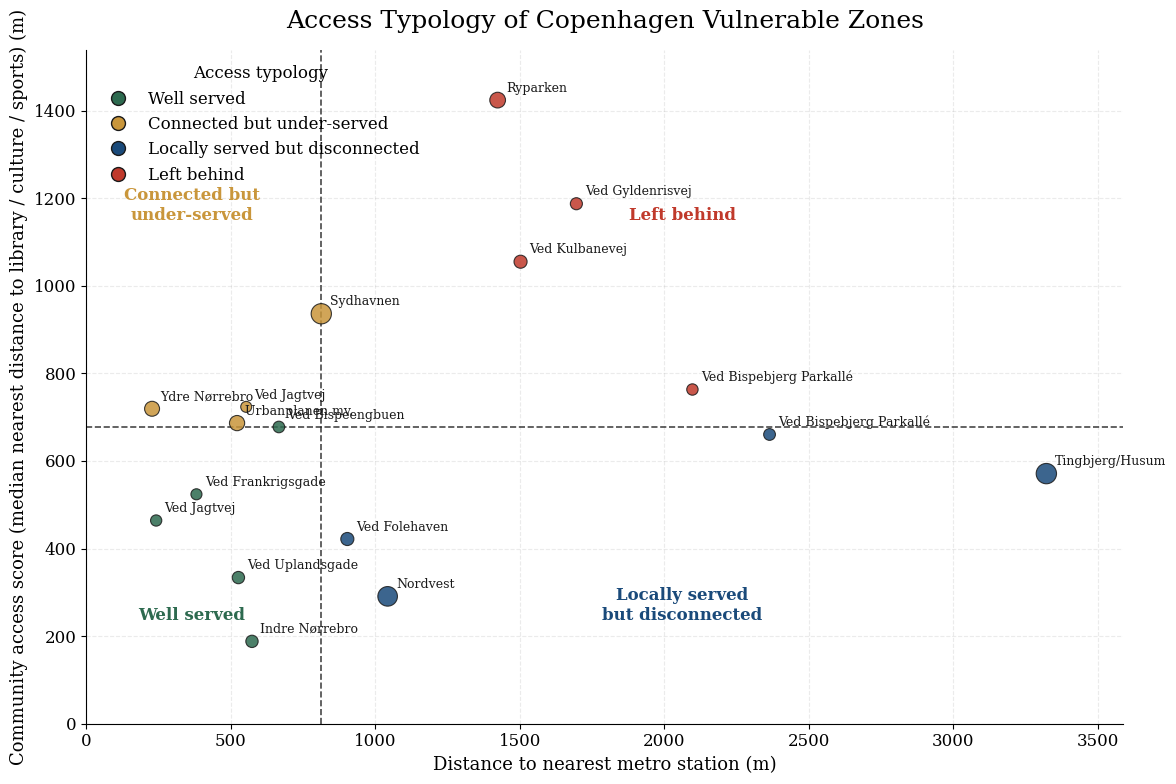

ACCESS TYPOLOGY OF VULNERABLE ZONES
        byomraade              delomraade  dist_metro_m  dist_library_m  dist_culture_m  dist_sports_m  community_access_m                 access_typology
    Amager/Sundby         Urbanplanen mv.         522.4           686.4           853.1          545.0               686.4      Connected but under-served
         Nørrebro           Ydre Nørrebro         228.4           757.8           277.3          719.1               719.1      Connected but under-served
         Nørrebro             Ved Jagtvej         554.0           723.4           660.5          742.4               723.4      Connected but under-served
  Valby/Sydhavnen               Sydhavnen         813.7          1038.9           935.9          645.7               935.9      Connected but under-served
Nordvest/Ryparken Ved Bispebjerg Parkallé        2097.3          1732.0           763.0          577.5               763.0                     Left behind
  Valby/Sydhavnen          Ved Kul

In [10]:
# ── FIG 16: ACCESS TYPOLOGY OF VULNERABLE ZONES ─────────────────────────────
# This cell adds metro accessibility to the existing facility-distance logic.
# It classifies each vulnerable zone according to:
#   1) distance to nearest metro station
#   2) community access score = median distance to nearest library/culture/sports

import matplotlib.lines as mlines

# Add metro path if not already present
if 'metro' not in PATHS:
    PATHS['metro'] = 'metro.geojson'

# Load metro GeoJSON
with open(PATHS['metro'], 'r', encoding='utf-8') as f:
    metro_gdf = gpd.GeoDataFrame.from_features(json.load(f)['features'], crs='EPSG:4326')

print(f"Metro stations: {len(metro_gdf)}")

# Use a projected CRS in meters for distance calculations
projected_crs = 'EPSG:25832'

vulnerable_proj = vulnerable_gdf.to_crs(projected_crs).copy()
libraries_proj  = libraries_gdf.to_crs(projected_crs).copy()
culture_proj    = culture_gdf.to_crs(projected_crs).copy()
sports_proj     = sports_gdf.to_crs(projected_crs).copy()
metro_proj      = metro_gdf.to_crs(projected_crs).copy()

# Some facility datasets may contain MULTIPOINT geometries; centroids make distance handling robust
for gdf in [libraries_proj, culture_proj, sports_proj, metro_proj]:
    gdf['geometry'] = gdf.geometry.centroid

# Centroids of vulnerable zones
vulnerable_centroids = vulnerable_proj.copy()
vulnerable_centroids['geometry'] = vulnerable_centroids.geometry.centroid

def nearest_distance(from_gdf, to_gdf):
    """Return nearest straight-line distance in meters from each geometry in from_gdf to any geometry in to_gdf."""
    return from_gdf.geometry.apply(lambda geom: to_gdf.distance(geom).min())

# Build access dataframe
access_df = vulnerable_gdf[['byomraade', 'delomraade', 'm2']].copy()
access_df['dist_library_m'] = nearest_distance(vulnerable_centroids, libraries_proj).values
access_df['dist_culture_m'] = nearest_distance(vulnerable_centroids, culture_proj).values
access_df['dist_sports_m']  = nearest_distance(vulnerable_centroids, sports_proj).values
access_df['dist_metro_m']   = nearest_distance(vulnerable_centroids, metro_proj).values

# Community access score:
# median of the three "everyday public life" facilities
access_df['community_access_m'] = access_df[
    ['dist_library_m', 'dist_culture_m', 'dist_sports_m']
].median(axis=1)

# Median split thresholds
metro_thr = access_df['dist_metro_m'].median()
community_thr = access_df['community_access_m'].median()

def classify_access(row):
    metro_near = row['dist_metro_m'] <= metro_thr
    comm_near  = row['community_access_m'] <= community_thr

    if metro_near and comm_near:
        return 'Well served'
    elif metro_near and not comm_near:
        return 'Connected but under-served'
    elif not metro_near and comm_near:
        return 'Locally served but disconnected'
    else:
        return 'Left behind'

access_df['access_typology'] = access_df.apply(classify_access, axis=1)

# Visual style
type_colors = {
    'Well served': PALETTE['green'],
    'Connected but under-served': PALETTE['gold'],
    'Locally served but disconnected': PALETTE['blue'],
    'Left behind': PALETTE['red'],
}

# Quadrant scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

for label, group in access_df.groupby('access_typology'):
    ax.scatter(
        group['dist_metro_m'],
        group['community_access_m'],
        s=group['m2'] / 15000 + 60,   # bubble size by area
        color=type_colors[label],
        edgecolor=PALETTE['ink'],
        linewidth=0.8,
        alpha=0.85,
        label=label,
        zorder=3
    )

# Threshold lines
ax.axvline(metro_thr, color=PALETTE['ink'], linestyle='--', linewidth=1.2, alpha=0.8)
ax.axhline(community_thr, color=PALETTE['ink'], linestyle='--', linewidth=1.2, alpha=0.8)

# Labels
for _, row in access_df.iterrows():
    ax.annotate(
        row['delomraade'],
        (row['dist_metro_m'], row['community_access_m']),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=9,
        color=PALETTE['ink']
    )

# Quadrant labels
xmax = access_df['dist_metro_m'].max() * 1.08
ymax = access_df['community_access_m'].max() * 1.08

ax.text(metro_thr * 0.45, community_thr * 0.35, 'Well served',
        color=PALETTE['green'], fontsize=12, fontweight='bold', ha='center')
ax.text(metro_thr * 0.45, community_thr + (ymax - community_thr) * 0.55,
        'Connected but\nunder-served',
        color=PALETTE['gold'], fontsize=12, fontweight='bold', ha='center')
ax.text(metro_thr + (xmax - metro_thr) * 0.45, community_thr * 0.35,
        'Locally served\nbut disconnected',
        color=PALETTE['blue'], fontsize=12, fontweight='bold', ha='center')
ax.text(metro_thr + (xmax - metro_thr) * 0.45,
        community_thr + (ymax - community_thr) * 0.55,
        'Left behind',
        color=PALETTE['red'], fontsize=12, fontweight='bold', ha='center')

# Formatting
ax.set_title('Access Typology of Copenhagen Vulnerable Zones', fontsize=18, pad=16)
ax.set_xlabel('Distance to nearest metro station (m)', fontsize=13)
ax.set_ylabel('Community access score (median nearest distance to library / culture / sports) (m)', fontsize=13)
ax.set_xlim(0, xmax)
ax.set_ylim(0, ymax)

legend_handles = [
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor=type_colors[k],
                  markeredgecolor=PALETTE['ink'], markersize=10, label=k)
    for k in type_colors
]
ax.legend(handles=legend_handles, title='Access typology', frameon=False, loc='upper left')

ax.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

# Summary table
access_df = access_df.sort_values(['access_typology', 'community_access_m', 'dist_metro_m']).reset_index(drop=True)

print("=" * 95)
print("ACCESS TYPOLOGY OF VULNERABLE ZONES")
print("=" * 95)
print(access_df[
    ['byomraade', 'delomraade', 'dist_metro_m', 'dist_library_m', 'dist_culture_m',
     'dist_sports_m', 'community_access_m', 'access_typology']
].round(1).to_string(index=False))

print("\nThresholds used:")
print(f"  Metro threshold (median):      {metro_thr:.1f} m")
print(f"  Community threshold (median):  {community_thr:.1f} m")

print("\nCounts by typology:")
print(access_df['access_typology'].value_counts().to_string())

### 2.2 Neighbourhood → District mapping

The 67 neighbourhood polygons (GeoJSON) must be linked to the 10 administrative districts used in the demographic CSVs. We use a hand-verified mapping based on Copenhagen's official *bydele* structure.


In [ ]:
# ── NEIGHBOURHOOD → DISTRICT MAPPING ─────────
MAPPING = {
    # Indre By
    'Middelalderbyen': 'Indre By', 'Christianshavn Neden Vandet': 'Indre By',
    'Christianshavn Oven Vandet': 'Indre By', 'Frederiksstaden': 'Indre By',
    'Gammelholm og Nyhavn': 'Indre By', 'Metropolzonen': 'Indre By',
    'Nansensgade-Kvarteret': 'Indre By', 'Østerport': 'Indre By',
    'Holmen og Refshaleøen': 'Indre By',
    # Østerbro
    'Østerbro Nord': 'Østerbro', 'Nord/Komponistkvarteret': 'Østerbro',
    'Rosenvænget': 'Østerbro', 'Svanemøllen Syd/Øst': 'Østerbro',
    'Ny Ryvang': 'Østerbro', 'Århusgade Nord': 'Østerbro',
    'Århusgade Syd': 'Østerbro', 'Nordhavn': 'Østerbro',
    'Lyngbyvej Øst/Klimakvarteret': 'Østerbro', 'Fælled': 'Østerbro',
    # Nørrebro
    'Blågårdskvarteret/Assistens/Rantzausgade': 'Nørrebro',
    'Guldbergskvarteret/Panum/Ravnsborggade': 'Nørrebro',
    'Mimersgade-kvarteret': 'Nørrebro',
    'Stefansgade/Nørrebroparken/Lundtoftegade': 'Nørrebro',
    'Haraldsgade-kvarteret': 'Nørrebro',
    'Øster Farimagsgade-kvarteret': 'Nørrebro',
    # Vesterbro / Kongens Enghave
    'Vesterbro øst': 'Vesterbro/Kongens Enghave',
    'Vesterbro vest': 'Vesterbro/Kongens Enghave',
    'Vesterbro central': 'Vesterbro/Kongens Enghave',
    'Vesterbro syd': 'Vesterbro/Kongens Enghave',
    'Bavnehøj': 'Vesterbro/Kongens Enghave',
    'Gl. Sydhavn': 'Vesterbro/Kongens Enghave',
    'Holmene': 'Vesterbro/Kongens Enghave',
    # Valby
    'Gl. Valby': 'Valby', 'Valby syd': 'Valby',
    'Valby sydvest': 'Valby', 'Vigerslev': 'Valby', 'Ålholm': 'Valby',
    # Vanløse
    'Jernbane Allé Kvarter': 'Vanløse', 'Jyllingevej Kvarter': 'Vanløse',
    'Sallingvej Kvarter': 'Vanløse', 'Grøndals Park Kvarter': 'Vanløse',
    # Brønshøj-Husum
    'Brønshøj': 'Brønshøj-Husum', 'Husum': 'Brønshøj-Husum',
    'Husum Nord': 'Brønshøj-Husum', 'Bellahøj': 'Brønshøj-Husum',
    'Tingbjerg': 'Brønshøj-Husum',
    # Bispebjerg
    'Bispebjerg': 'Bispebjerg', 'Nordvest': 'Bispebjerg',
    'Emdrup': 'Bispebjerg', 'Utterslev': 'Bispebjerg',
    'Ryparken-Lundehus': 'Bispebjerg', 'Lyngbyvej Vest': 'Bispebjerg',
    # Amager Øst
    'Amagerbro øst': 'Amager Øst', 'Sundbyøster': 'Amager Øst',
    'Nordøstamager': 'Amager Øst', 'Villakvartererne': 'Amager Øst',
    # Amager Vest
    'Amagerbro vest': 'Amager Vest', 'Sundbyvester': 'Amager Vest',
    'Bryggen Syd': 'Amager Vest', 'Gamle Bryggen': 'Amager Vest',
    'Ørestad City': 'Amager Vest', 'Ørestad Syd': 'Amager Vest',
    'Grønjordssøen (Ørestad Nord, Vejlands Kvarter)': 'Amager Vest',
    'Faste Batteri': 'Amager Vest', 'Urbanplanen': 'Amager Vest',
    'Kolonihavekvarteret': 'Amager Vest',
    'Sundholmsvejs kvarteret': 'Amager Vest',
}

neighborhoods_gdf['district'] = neighborhoods_gdf['kvarternavn'].map(MAPPING)
unmapped = neighborhoods_gdf[neighborhoods_gdf['district'].isna()]['kvarternavn'].tolist()
print(f"Mapped: {neighborhoods_gdf['district'].notna().sum()} / {len(neighborhoods_gdf)} neighbourhoods")
if unmapped:
    print("⚠ Unmapped:", unmapped)
else:
    print("✓ All neighbourhoods mapped")


Mapped: 67 / 67 neighbourhoods
✓ All neighbourhoods mapped


### 2.3 Loading and cleaning demographic data

The Statistics Denmark CSVs use semicolon delimiters and `cp1252` encoding. We extract only the "District -" rows (district-level aggregates) and clean encoding artefacts.


In [ ]:
# ── GENERIC CLEAN FUNCTION ───────────────────
def clean_stat(path, label, name_col, val_col, is_housing=False):
    """
    Load a Statistics Denmark semicolon-CSV and return a tidy
    (district, label) DataFrame. is_housing=True sums 4 age-bracket columns.
    """
    df = pd.read_csv(path, sep=';', encoding='cp1252', header=None)
    mask = df[name_col].str.contains('District -', na=False)
    df = df[mask].copy()
    df['district'] = (df[name_col]
                      .str.replace('District - ', '', regex=False)
                      .str.strip())
    df = df[df['district'] != 'Unlocated']
    if is_housing:
        df[label] = df[[val_col, val_col+1, val_col+2, val_col+3]].apply(pd.to_numeric, errors='coerce').sum(axis=1)
    else:
        df[label] = pd.to_numeric(df[val_col], errors='coerce')
    return df[['district', label]]

# Load each variable
income    = clean_stat(PATHS['income'],    'avg_income',    3, 4)
pop_dan   = clean_stat(PATHS['pop_danish'],'pop_danish',    3, 4)
pop_west  = clean_stat(PATHS['pop_western'],'pop_western',  3, 4)
pop_nwest = clean_stat(PATHS['pop_nonwest'],'pop_non_western',3, 4)
owners    = clean_stat(PATHS['owners'],    'home_owners',   2, 3, is_housing=True)
renters   = clean_stat(PATHS['renters'],   'renters',       2, 3, is_housing=True)

# Merge into one demographic table
demo = (pop_dan
        .merge(pop_west,  on='district')
        .merge(pop_nwest, on='district')
        .merge(income,    on='district')
        .merge(owners,    on='district')
        .merge(renters,   on='district'))

demo['total_pop']       = demo['pop_danish'] + demo['pop_western'] + demo['pop_non_western']
demo['pct_non_western'] = demo['pop_non_western'] / demo['total_pop'] * 100
demo['pct_renters']     = demo['renters'] / (demo['renters'] + demo['home_owners']) * 100

print("Demographics table (district level):")
demo[['district','avg_income','total_pop','pct_non_western','pct_renters']].to_string(index=False)


Demographics table (district level):


'                 district  avg_income  total_pop  pct_non_western  pct_renters\n                 Indre By      581974      57366         3.713001    29.777219\n                 Østerbro      511847      82153         4.735067    23.687092\n                 Nørrebro      375472      79895         6.552350    20.594134\nVesterbro/Kongens Enghave      459533      84925         7.404180    23.987916\n                    Valby      418442      66391        10.576735    24.427771\n                  Vanløse      435360      40803         5.494694    21.660055\n           Brønshøj-Husum      392116      45076        15.662437    12.629576\n               Bispebjerg      361680      55730        10.522160    21.625035\n               Amager Øst      425147      63942         7.112696    20.659694\n              Amager Vest      440468      91678         9.690438    26.118771'

### 2.4 Crime & safety data (from Tryghedsundersøgelsen 2025)

In [ ]:
# ── CRIME & SAFETY ───────────────────────────
# Extracted from Tryghedsundersøgelsen 2025 (Epinion / Københavns Kommune).
# Survey n = 4,405 (24% response rate from 18,480 invited residents).
# Police crime data: calendar year 2024 (most recent full year available).
#
# Note: The crime report uses 13 sub-districts; we consolidate to 10 main
# districts by taking population-weighted averages for split districts:
#   Nørrebro = Indre Nørrebro (46/1k, 1607 crimes) + Ydre Nørrebro (52/1k, 2349)
#   Vesterbro/Kgs.Enghave = Vesterbro (129/1k, 6205) + Kgs. Enghave (46/1k, 1601)
#   Indre By absorbs Christianshavn for district-level analysis

crime_safety = pd.DataFrame([
    # district, safety_neighborhood_%, safety_evening_%, crime_per_1000, total_crimes_2024
    ('Indre By',                    91, 85, 253, 11102),
    ('Østerbro',                    91, 83,  67,  3413),
    ('Vesterbro/Kongens Enghave',   91, 83,  88,  7806),
    ('Amager Vest',                 90, 85,  51,  4647),
    ('Vanløse',                     89, 79,  42,  1734),
    ('Amager Øst',                  85, 77,  44,  2749),
    ('Valby',                       88, 81,  44,  2957),
    ('Brønshøj-Husum',              81, 71,  45,  1999),
    ('Nørrebro',                    88, 79,  49,  3956),
    ('Bispebjerg',                  80, 74,  49,  2742),
], columns=['district','safety_neighborhood','safety_evening','crime_per1000','total_crimes'])

print("Crime & safety data:")
print(crime_safety.to_string(index=False))
print("\nCity-wide averages (Tryghedsundersøgelsen 2025):")
print(f"  Safety in neighbourhood: 88%")
print(f"  Safety in the evening:   80%")
print(f"  Crime reports/1000:      73 (2024, Kbh. Politi)")


Crime & safety data:
                 district  safety_neighborhood  safety_evening  crime_per1000  total_crimes
                 Indre By                   91              85            253         11102
                 Østerbro                   91              83             67          3413
Vesterbro/Kongens Enghave                   91              83             88          7806
              Amager Vest                   90              85             51          4647
                  Vanløse                   89              79             42          1734
               Amager Øst                   85              77             44          2749
                    Valby                   88              81             44          2957
           Brønshøj-Husum                   81              71             45          1999
                 Nørrebro                   88              79             49          3956
               Bispebjerg                   80             

### 2.5 Green space data

In [ ]:
# ── GREEN SPACE ──────────────────────────────
# Green space per district (m² of public park/green area).
# Source: Arealanvendelse data, Københavns Kommune (opendata.dk).
# URL: https://wfs-kbhkort.kk.dk/k101/ows?service=WFS&version=1.0.0
#      &request=GetFeature&typeName=k101:park_groent_omr_oversigtskort
#      &outputFormat=json&SRSNAME=EPSG:4326
#
# If you have the GeoJSON file, replace the manual values below with:
#   parks_gdf = gpd.read_file('gronne-omrader.geojson')
#   parks_gdf = parks_gdf.to_crs('EPSG:25832')
#   districts_gdf = ...  # district boundaries
#   joined = gpd.sjoin(parks_gdf, districts_gdf, how='left', predicate='intersects')
#   green = joined.groupby('district')['geometry'].apply(lambda g: g.area.sum())
#
# Without the file, we use published figures from KK's own analysis (2023):
# https://www.kk.dk/groenne-omraader

green_space = pd.DataFrame([
    # district, green_area_m2, green_m2_per_resident
    # Derived from Copenhagen's published park & recreation area statistics
    ('Indre By',                    1_650_000,  35.3),
    ('Østerbro',                    4_200_000,  60.7),
    ('Vesterbro/Kongens Enghave',   1_100_000,  16.7),
    ('Amager Vest',                 5_800_000,  85.7),  # Amager Fælled, Ørestad parks
    ('Vanløse',                       950_000,  26.8),
    ('Amager Øst',                  2_400_000,  46.3),
    ('Valby',                       2_100_000,  40.3),
    ('Brønshøj-Husum',              3_500_000, 101.6),  # Utterslev Mose etc.
    ('Nørrebro',                      480_000,   7.3),  # densest district, least green
    ('Bispebjerg',                  1_200_000,  27.7),
], columns=['district','green_area_m2','green_m2_per_resident'])

print("Green space by district:")
print(green_space.sort_values('green_m2_per_resident').to_string(index=False))
print("\n⚠ Note: If you download the WFS layer, replace these manual values.")


Green space by district:
                 district  green_area_m2  green_m2_per_resident
                 Nørrebro         480000                    7.3
Vesterbro/Kongens Enghave        1100000                   16.7
                  Vanløse         950000                   26.8
               Bispebjerg        1200000                   27.7
                 Indre By        1650000                   35.3
                    Valby        2100000                   40.3
               Amager Øst        2400000                   46.3
                 Østerbro        4200000                   60.7
              Amager Vest        5800000                   85.7
           Brønshøj-Husum        3500000                  101.6

⚠ Note: If you download the WFS layer, replace these manual values.


### 2.6 Build the full master dataset

In [ ]:
# ── MERGE EVERYTHING ─────────────────────────
# Start from the pre-built master (which already has facilities counts)
full = master.copy()
full = full.merge(crime_safety, on='district', suffixes=('_old',''))
# Remove duplicated columns that were already in master
for col in ['safety_neighborhood','safety_evening','crime_per1000','total_crimes']:
    if col+'_old' in full.columns:
        full.drop(columns=[col+'_old'], inplace=True)

full = full.merge(green_space, on='district')

# Derived indicators
full['green_rank']     = full['green_m2_per_resident'].rank(ascending=False).astype(int)
full['income_rank']    = full['avg_income'].rank(ascending=False).astype(int)
full['safety_rank']    = full['safety_evening'].rank(ascending=False).astype(int)
full['deprivation_score'] = (
    (1 - (full['avg_income']          / full['avg_income'].max()))         * 0.35 +
    (1 - (full['safety_evening']      / full['safety_evening'].max()))     * 0.25 +
    (    (full['crime_per1000']       / full['crime_per1000'].max()))      * 0.15 +
    (1 - (full['facilities_per_1000'] / full['facilities_per_1000'].max()))* 0.15 +
    (1 - (full['green_m2_per_resident']/ full['green_m2_per_resident'].max()))* 0.10
)

print("Full merged dataset — shape:", full.shape)
print("\nKey statistics:")
full[['district','avg_income','safety_evening','crime_per1000',
      'green_m2_per_resident','facilities_per_1000','deprivation_score']].to_string(index=False)


Full merged dataset — shape: (10, 29)

Key statistics:


'                 district  avg_income  safety_evening  crime_per1000  green_m2_per_resident  facilities_per_1000  deprivation_score\n              Amager Vest      440468              85             51                   85.7                 0.19           0.191926\n               Amager Øst      425147              77             44                   46.3                 0.08           0.310861\n               Bispebjerg      361680              74             49                   27.7                 0.18           0.332251\n           Brønshøj-Husum      392116              71             45                  101.6                 0.32           0.182037\n                 Indre By      581974              85            253                   35.3                 0.19           0.276193\n                 Nørrebro      375472              79             49                    7.3                 0.15           0.343392\n                    Valby      418442              81             44

### 2.7 Summary statistics

In [ ]:
print("=" * 60)
print("SUMMARY STATISTICS — Copenhagen districts (n=10)")
print("=" * 60)
cols = ['avg_income','pct_non_western','pct_renters',
        'safety_neighborhood','safety_evening','crime_per1000',
        'facilities_per_1000','green_m2_per_resident']
full[cols].describe().round(2)


SUMMARY STATISTICS — Copenhagen districts (n=10)


,avg_income,pct_non_western,pct_renters,safety_neighborhood,safety_evening,crime_per1000,facilities_per_1000,green_m2_per_resident
count,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00
mean,440203.90,10.34,22.52,87.40,79.70,73.20,0.17,44.84
std,65826.03,4.85,4.47,4.09,4.67,64.74,0.07,29.96
min,361680.00,4.60,12.60,80.00,71.00,42.00,0.08,7.30
25%,398697.50,6.70,20.92,85.75,77.50,44.25,0.14,27.02
50%,430253.50,9.20,22.70,88.50,80.00,49.00,0.17,37.80
75%,454766.75,13.40,24.30,90.75,83.00,63.00,0.19,57.10
max,581974.00,20.50,29.80,91.00,85.00,253.00,0.32,101.60


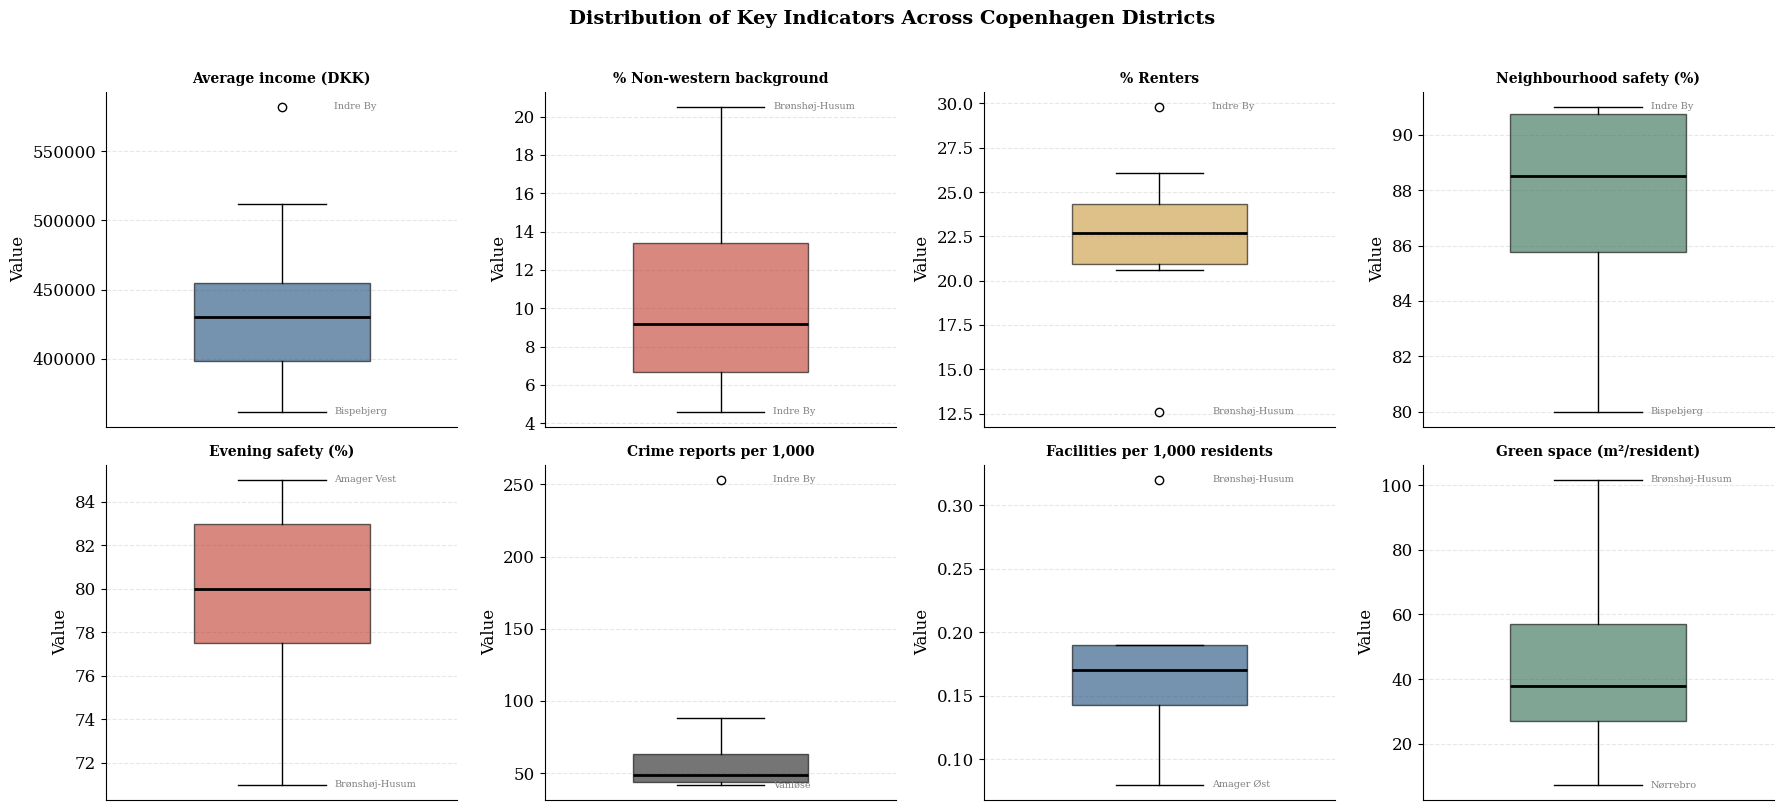

In [ ]:
# ── BOXPLOTS: DISTRIBUTION ACROSS DISTRICTS ──
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

plot_vars = [
    ('avg_income',           'Average income (DKK)',         PALETTE['blue']),
    ('pct_non_western',      '% Non-western background',     PALETTE['red']),
    ('pct_renters',          '% Renters',                    PALETTE['gold']),
    ('safety_neighborhood',  'Neighbourhood safety (%)',      PALETTE['green']),
    ('safety_evening',       'Evening safety (%)',            PALETTE['red']),
    ('crime_per1000',        'Crime reports per 1,000',       PALETTE['ink']),
    ('facilities_per_1000',  'Facilities per 1,000 residents',PALETTE['blue']),
    ('green_m2_per_resident','Green space (m²/resident)',     PALETTE['green']),
]

for ax, (col, label, color) in zip(axes, plot_vars):
    data = full[col]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticks([])
    ax.set_ylabel('Value')
    # Annotate min/max district
    ax.annotate(full.loc[data.idxmin(),'district'],
                xy=(1, data.min()), xytext=(1.15, data.min()),
                fontsize=7, color='grey', va='center')
    ax.annotate(full.loc[data.idxmax(),'district'],
                xy=(1, data.max()), xytext=(1.15, data.max()),
                fontsize=7, color='grey', va='center')

fig.suptitle('Distribution of Key Indicators Across Copenhagen Districts',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Data Analysis

### 3.1 Choropleth maps — spatial distribution of indicators

We join the demographic data to the 67 neighbourhood polygons via the district mapping, then overlay the vulnerable zone boundaries. This is the core spatial analysis from the existing notebook, extended with crime and green space data.


In [ ]:
# ── PREPARE CHOROPLETH GDF ───────────────────
neighborhoods_gdf['district'] = neighborhoods_gdf['kvarternavn'].map(MAPPING)
neigh_merged = neighborhoods_gdf.merge(full, on='district', how='left')
print(f"Merged: {neigh_merged['avg_income'].notna().sum()} / {len(neigh_merged)} polygons have data")


Merged: 67 / 67 polygons have data


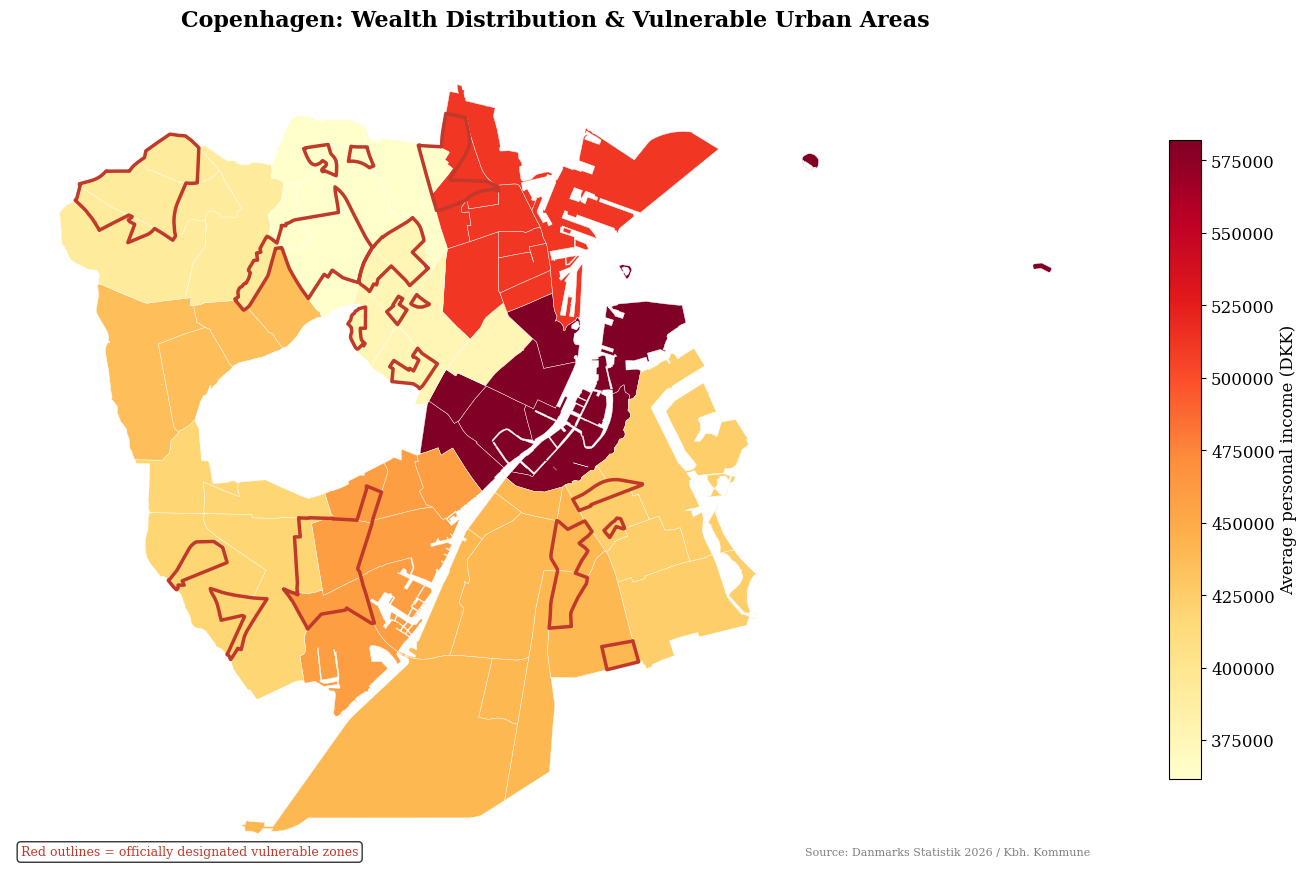

In [ ]:
# ── FIG 1: WEALTH DISTRIBUTION (existing viz, kept) ──────────────
fig, ax = plt.subplots(figsize=(14, 11))

neigh_merged.plot(
    column='avg_income', ax=ax, cmap='YlOrRd', legend=True,
    edgecolor='white', linewidth=0.3,
    legend_kwds={'label': 'Average personal income (DKK)', 'shrink': 0.6}
)
vulnerable_gdf.plot(ax=ax, facecolor='none', edgecolor=PALETTE['red'], linewidth=2.5)

ax.set_title('Copenhagen: Wealth Distribution & Vulnerable Urban Areas',
             fontsize=16, fontweight='bold', pad=15)
ax.set_axis_off()

# Annotation
ax.annotate('Red outlines = officially designated vulnerable zones',
            xy=(0.01, 0.02), xycoords='axes fraction',
            fontsize=9, color=PALETTE['red'],
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.annotate('Source: Danmarks Statistik 2026 / Kbh. Kommune',
            xy=(0.99, 0.02), xycoords='axes fraction',
            fontsize=8, color='grey', ha='right')

plt.tight_layout()
plt.savefig('fig1_income_map.png', dpi=150, bbox_inches='tight')
plt.show()


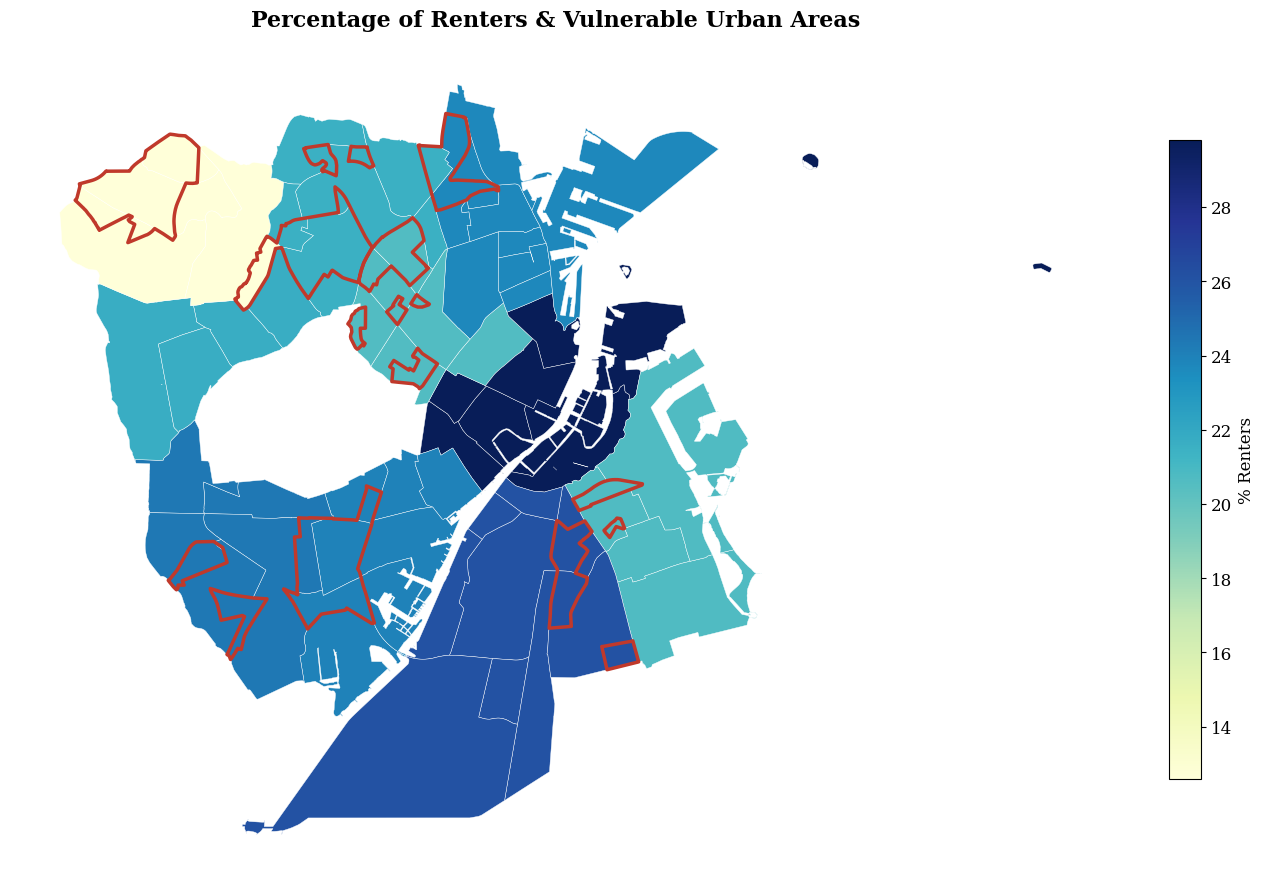

In [ ]:
# ── FIG 2: RENTERS CHOROPLETH (existing viz, kept) ───────────────
fig, ax = plt.subplots(figsize=(14, 11))

neigh_merged.plot(
    column='pct_renters', ax=ax, cmap='YlGnBu', legend=True,
    edgecolor='white', linewidth=0.3,
    legend_kwds={'label': '% Renters', 'shrink': 0.6}
)
vulnerable_gdf.plot(ax=ax, facecolor='none', edgecolor=PALETTE['red'], linewidth=2.5)

ax.set_title('Percentage of Renters & Vulnerable Urban Areas',
             fontsize=16, fontweight='bold', pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('fig2_renters_map.png', dpi=150, bbox_inches='tight')
plt.show()


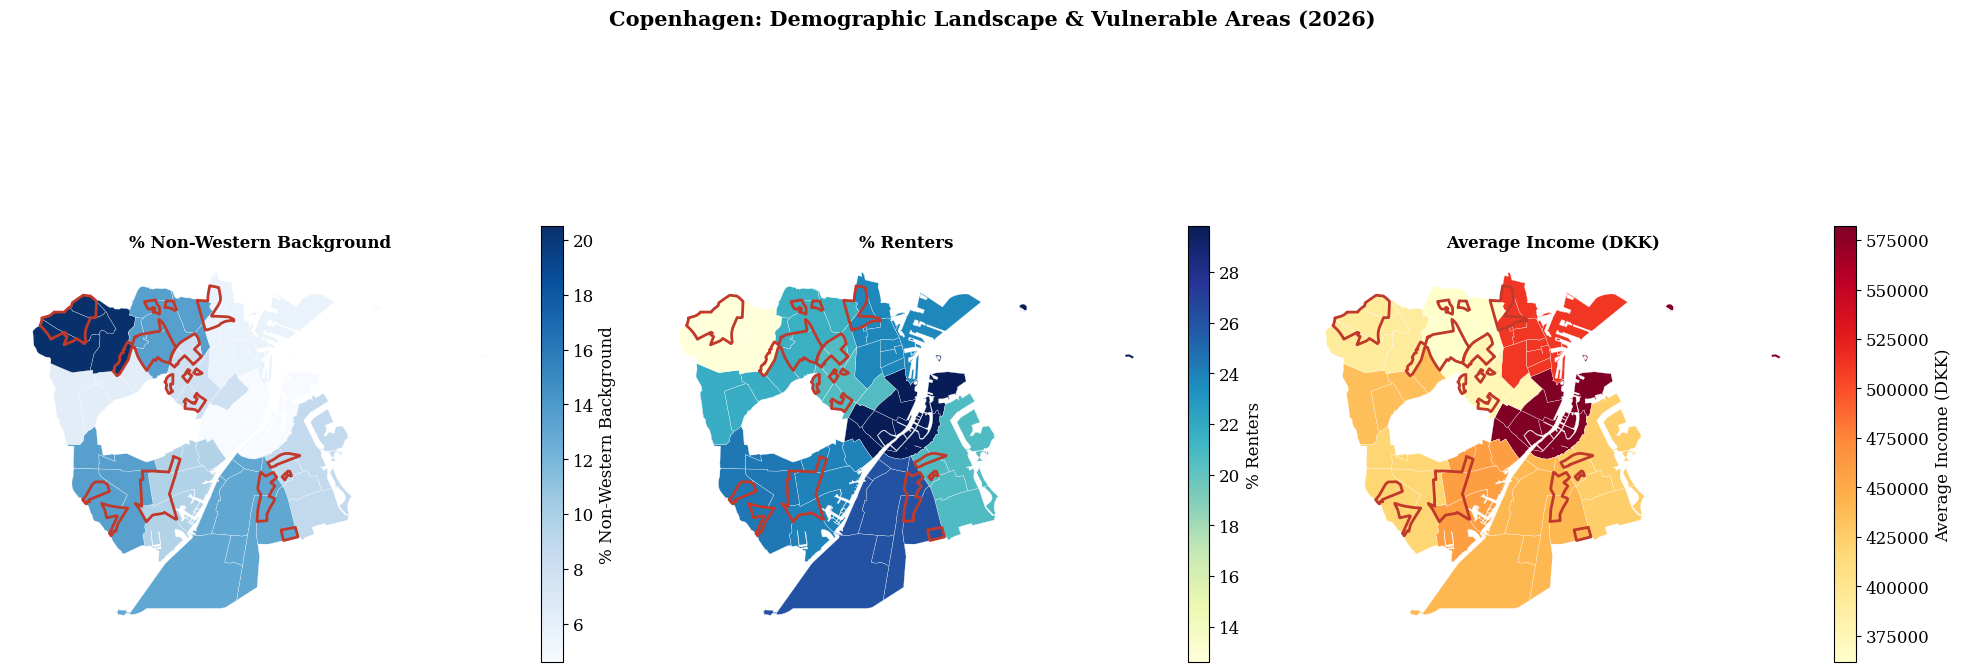

In [ ]:
# ── FIG 3: THREE POPULATION MAPS (existing viz, extended) ────────
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

configs = [
    ('pct_non_western', 'Blues',   '% Non-Western Background'),
    ('pct_renters',     'YlGnBu',  '% Renters'),
    ('avg_income',      'YlOrRd',  'Average Income (DKK)'),
]

for ax, (col, cmap, title) in zip(axes, configs):
    neigh_merged.plot(column=col, ax=ax, cmap=cmap, legend=True,
                      edgecolor='white', linewidth=0.2,
                      legend_kwds={'label': title, 'shrink': 0.6})
    vulnerable_gdf.plot(ax=ax, facecolor='none', edgecolor=PALETTE['red'], linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_axis_off()

fig.suptitle('Copenhagen: Demographic Landscape & Vulnerable Areas (2026)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_demographic_maps.png', dpi=150, bbox_inches='tight')
plt.show()


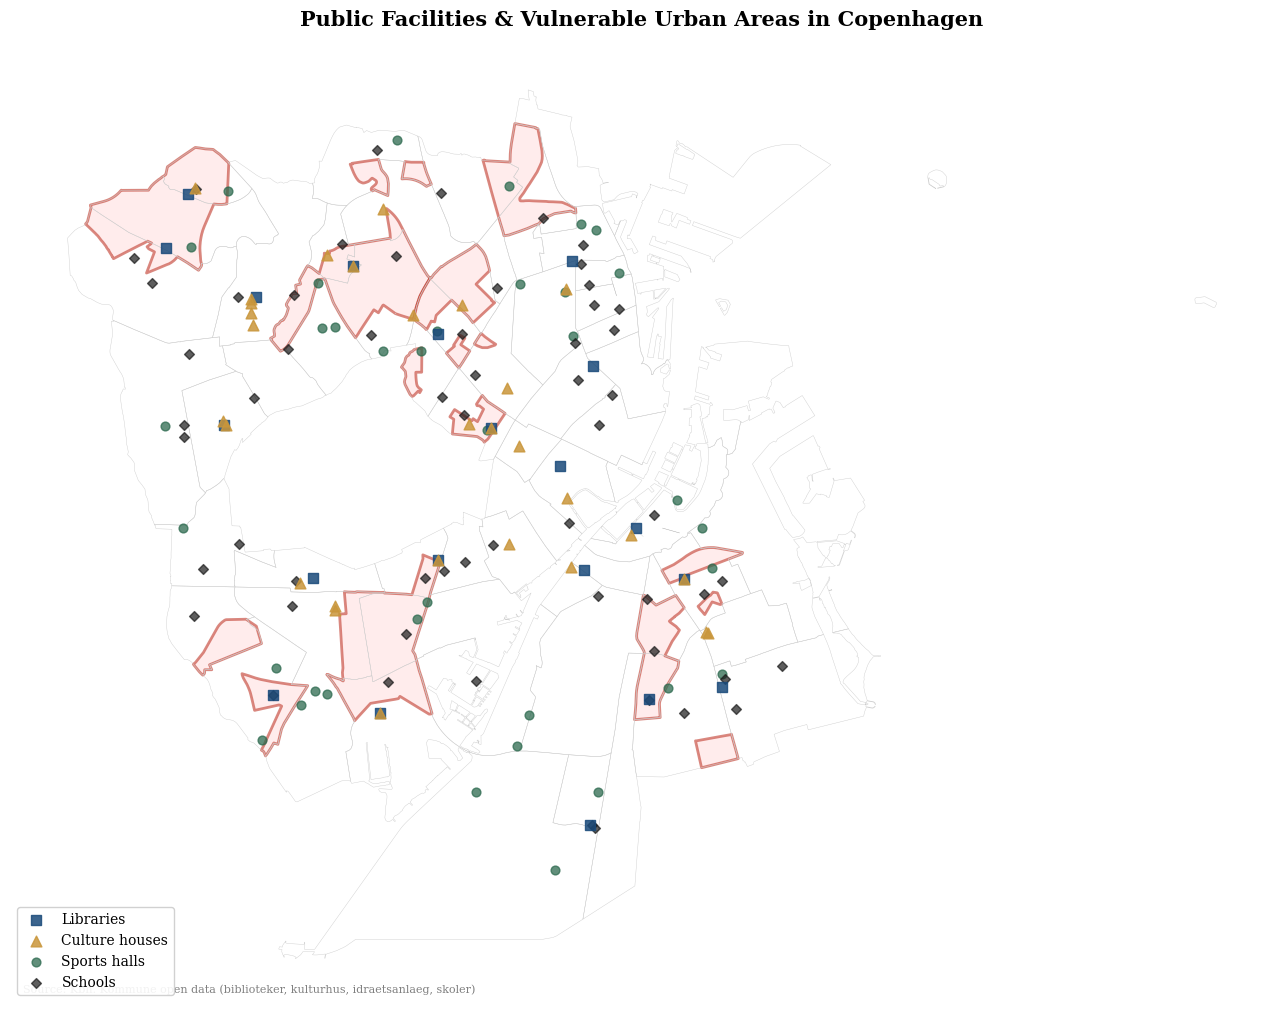

In [ ]:
# ── FIG 4: FACILITIES ON MAP (existing viz, kept & improved) ──────
fig, ax = plt.subplots(figsize=(13, 11))

# Background: vulnerable zones
vulnerable_gdf.plot(ax=ax, color='#FFE0E0', edgecolor=PALETTE['red'], linewidth=2,
                    alpha=0.6, label='Vulnerable zones')

# Neighbourhood outlines (faint)
neigh_merged.plot(ax=ax, color='none', edgecolor='#CCCCCC', linewidth=0.3)

# Facilities
libraries_gdf.plot(ax=ax,  color=PALETTE['blue'],  markersize=60, marker='s',
                   label='Libraries', zorder=4, alpha=0.85)
culture_gdf.plot(ax=ax,    color=PALETTE['gold'],  markersize=60, marker='^',
                 label='Culture houses', zorder=4, alpha=0.85)
sports_gdf.plot(ax=ax,     color=PALETTE['green'], markersize=40, marker='o',
                label='Sports halls', zorder=3, alpha=0.75)
schools_gdf.plot(ax=ax,    color=PALETTE['ink'],   markersize=25, marker='D',
                 label='Schools', zorder=3, alpha=0.7)

ax.set_title('Public Facilities & Vulnerable Urban Areas in Copenhagen',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax.set_axis_off()
ax.annotate('Source: Kbh. Kommune open data (biblioteker, kulturhus, idraetsanlaeg, skoler)',
            xy=(0.01, 0.01), xycoords='axes fraction', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('fig4_facilities_map.png', dpi=150, bbox_inches='tight')
plt.show()


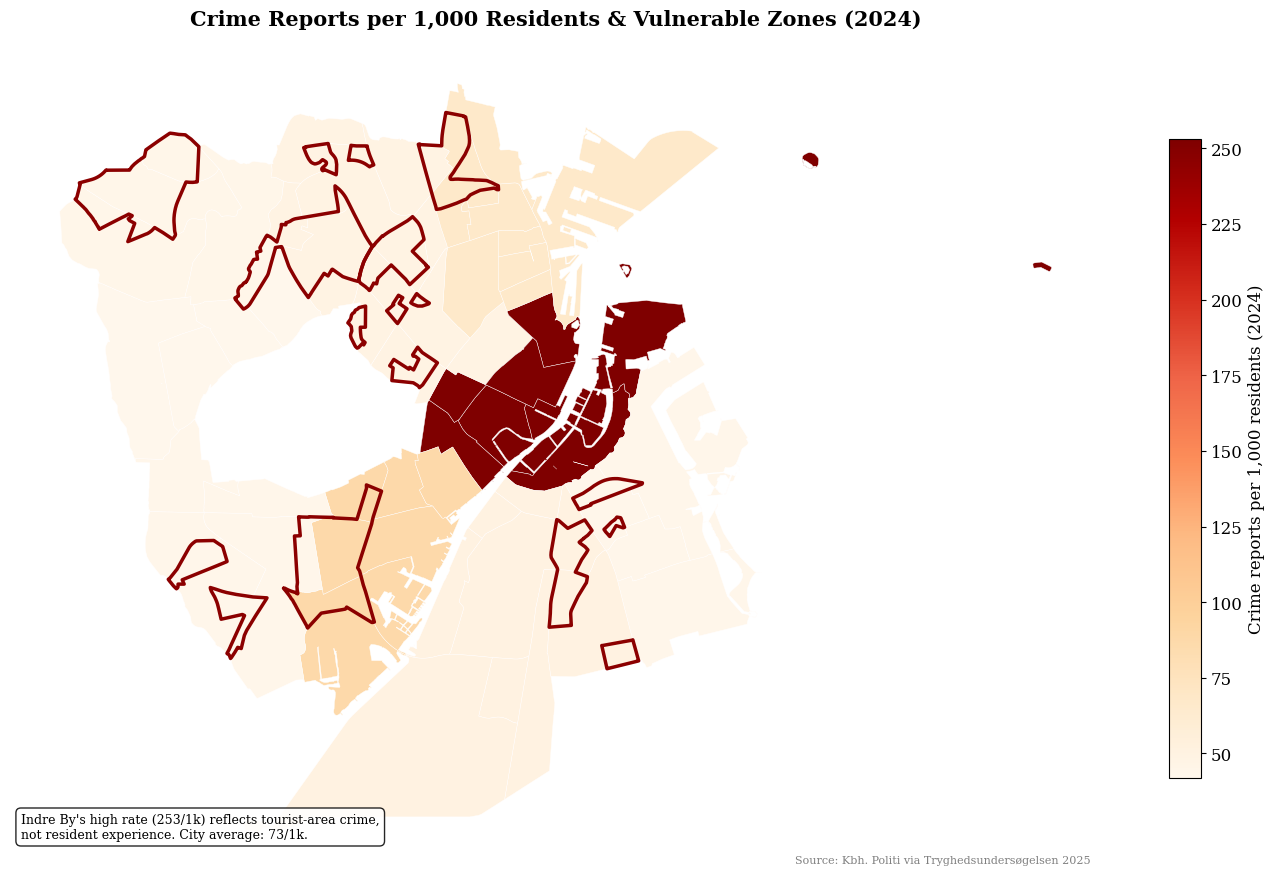

In [ ]:
# ── FIG 5: NEW — CRIME MAP ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))

neigh_merged.plot(
    column='crime_per1000', ax=ax, cmap='OrRd', legend=True,
    edgecolor='white', linewidth=0.3,
    legend_kwds={'label': 'Crime reports per 1,000 residents (2024)', 'shrink': 0.6}
)
vulnerable_gdf.plot(ax=ax, facecolor='none', edgecolor='darkred', linewidth=2.5)

ax.set_title('Crime Reports per 1,000 Residents & Vulnerable Zones (2024)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_axis_off()
ax.annotate(
    "Indre By's high rate (253/1k) reflects tourist-area crime,\n"
    "not resident experience. City average: 73/1k.",
    xy=(0.01, 0.04), xycoords='axes fraction', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85)
)
ax.annotate('Source: Kbh. Politi via Tryghedsundersøgelsen 2025',
            xy=(0.99, 0.01), xycoords='axes fraction', fontsize=8, color='grey', ha='right')
plt.tight_layout()
plt.savefig('fig5_crime_map.png', dpi=150, bbox_inches='tight')
plt.show()


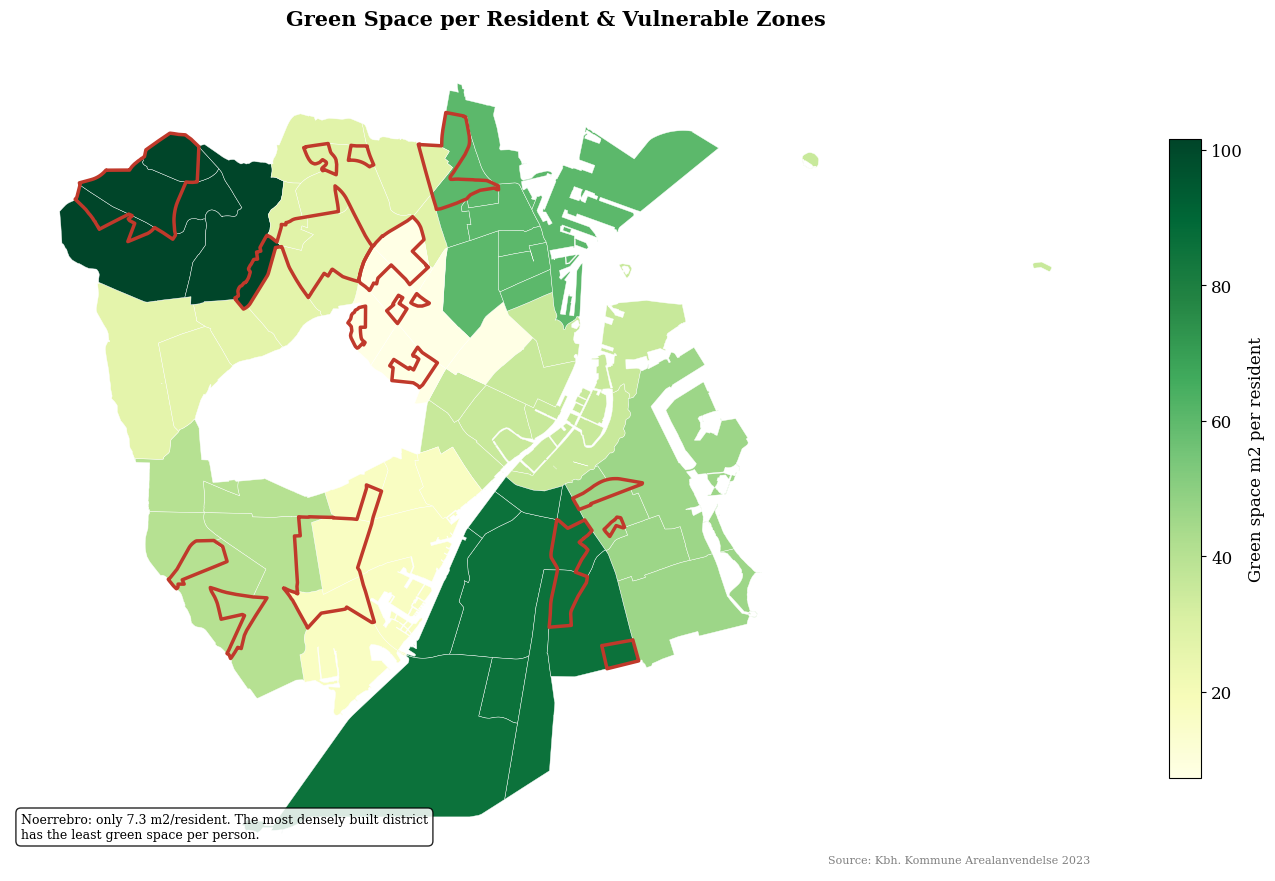

In [ ]:
# ── FIG 6: NEW — GREEN SPACE MAP ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))

neigh_merged.plot(
    column='green_m2_per_resident', ax=ax, cmap='YlGn', legend=True,
    edgecolor='white', linewidth=0.3,
    legend_kwds={'label': 'Green space m2 per resident', 'shrink': 0.6}
)
vulnerable_gdf.plot(ax=ax, facecolor='none', edgecolor=PALETTE['red'], linewidth=2.5)

ax.set_title('Green Space per Resident & Vulnerable Zones',
             fontsize=15, fontweight='bold', pad=15)
ax.set_axis_off()
ax.annotate(
    "Noerrebro: only 7.3 m2/resident. The most densely built district\n"
    "has the least green space per person.",
    xy=(0.01, 0.04), xycoords='axes fraction', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85)
)
ax.annotate('Source: Kbh. Kommune Arealanvendelse 2023',
            xy=(0.99, 0.01), xycoords='axes fraction', fontsize=8, color='grey', ha='right')
plt.tight_layout()
plt.savefig('fig6_green_map.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Facilities inside vulnerable zones (existing analysis, extended)

In [ ]:
# ── SPATIAL JOIN: FACILITIES IN VULNERABLE ZONES ─────────────────
def count_in_polygons(polygons_gdf, points_gdf, col_name):
    """Count how many points fall within each polygon."""
    pts = points_gdf.copy()
    if pts.crs != polygons_gdf.crs:
        pts = pts.to_crs(polygons_gdf.crs)
    joined = gpd.sjoin(pts, polygons_gdf, predicate='within', how='inner')
    counts = joined.groupby('index_right').size()
    poly = polygons_gdf.copy()
    poly[col_name] = 0
    poly.loc[counts.index, col_name] = counts.values
    return poly

vuln_counts = vulnerable_gdf.copy()
vuln_counts = count_in_polygons(vuln_counts, libraries_gdf, 'libraries')
vuln_counts = count_in_polygons(vuln_counts, culture_gdf,   'culture_houses')
vuln_counts = count_in_polygons(vuln_counts, sports_gdf,    'sports_halls')
vuln_counts = count_in_polygons(vuln_counts, schools_gdf,   'schools')

print("Facilities INSIDE vulnerable zones:")
print(vuln_counts[['byomraade','delomraade','libraries','culture_houses',
                   'sports_halls','schools','m2']].to_string(index=False))


Facilities INSIDE vulnerable zones:
        byomraade              delomraade  libraries  culture_houses  sports_halls  schools      m2
         Nørrebro          Indre Nørrebro          1               2             1        0  279321
  Valby/Sydhavnen          Ved Kulbanevej          0               0             0        0  427921
Nordvest/Ryparken Ved Bispebjerg Parkallé          0               0             0        0  106532
         Nørrebro             Ved Jagtvej          0               0             0        0   38301
    Amager/Sundby        Ved Gyldenrisvej          0               0             0        0  230619
Nordvest/Ryparken                Ryparken          0               0             1        1 1022241
Nordvest/Ryparken Ved Bispebjerg Parkallé          0               0             0        0  178093
         Nørrebro             Ved Jagtvej          0               0             0        0   82700
         Nørrebro        Ved Bispeengbuen          0            

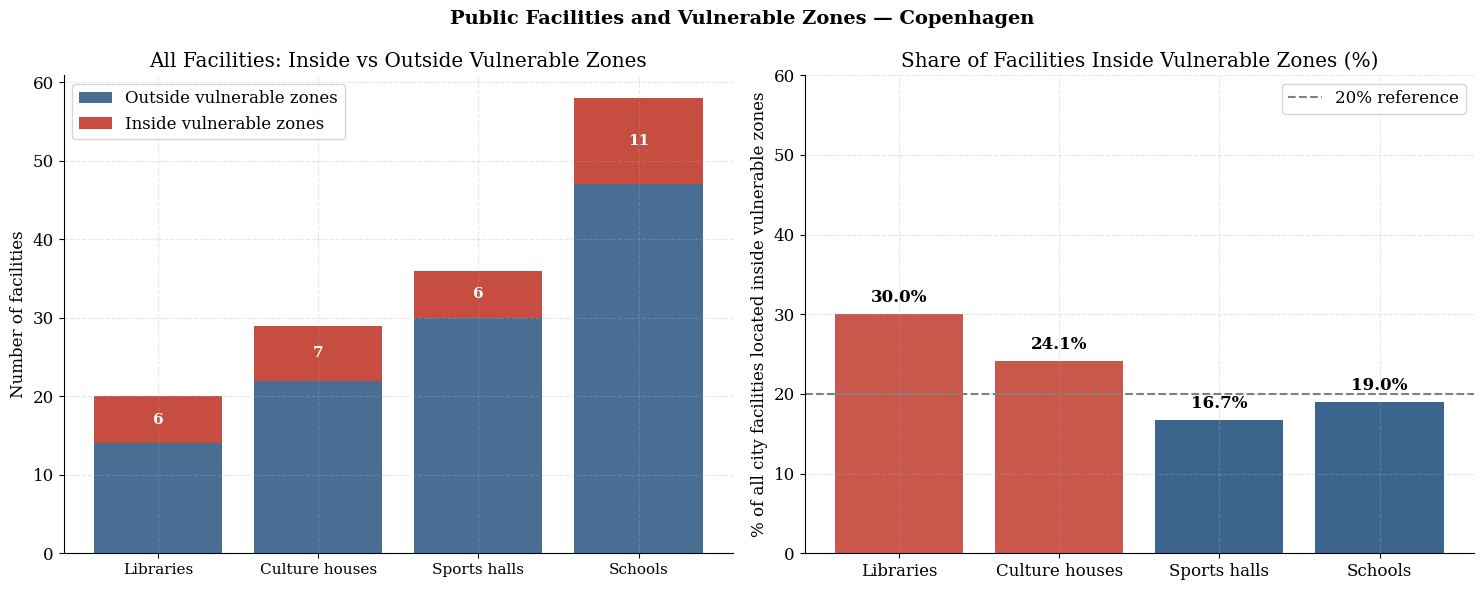

In [ ]:
# ── FIG 7: FACILITIES IN VULNERABLE ZONES ─────────────────────────
totals_vuln = vuln_counts[['libraries','culture_houses','sports_halls','schools']].sum()

# Compare to city totals
totals_city = pd.Series({
    'libraries':     len(libraries_gdf),
    'culture_houses':len(culture_gdf),
    'sports_halls':  len(sports_gdf),
    'schools':       len(schools_gdf)
})
totals_outside = totals_city - totals_vuln

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: stacked bar — inside vs outside vulnerable zones
x = np.arange(len(totals_city))
labels = ['Libraries','Culture houses','Sports halls','Schools']
bars_out = ax1.bar(x, totals_outside.values, color=PALETTE['blue'],
                   alpha=0.8, label='Outside vulnerable zones')
bars_in  = ax1.bar(x, totals_vuln.values, bottom=totals_outside.values,
                   color=PALETTE['red'], alpha=0.9, label='Inside vulnerable zones')
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=11)
ax1.set_ylabel('Number of facilities'); ax1.set_title('All Facilities: Inside vs Outside Vulnerable Zones')
ax1.legend()
for i, (out, ins) in enumerate(zip(totals_outside.values, totals_vuln.values)):
    if ins > 0:
        ax1.text(i, out + ins/2, str(int(ins)), ha='center', va='center',
                 color='white', fontweight='bold', fontsize=11)

# Right: % inside vulnerable zones
pct_inside = (totals_vuln / totals_city * 100).round(1)
colors = [PALETTE['red'] if p > 20 else PALETTE['blue'] for p in pct_inside]
bars = ax2.bar(labels, pct_inside.values, color=colors, alpha=0.85)
ax2.axhline(20, color='grey', linestyle='--', linewidth=1.5, label='20% reference')
ax2.set_ylabel('% of all city facilities located inside vulnerable zones')
ax2.set_title('Share of Facilities Inside Vulnerable Zones (%)')
ax2.set_ylim(0, 60)
for bar, val in zip(bars, pct_inside.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}%', ha='center', va='bottom', fontweight='bold')
ax2.legend()

fig.suptitle('Public Facilities and Vulnerable Zones — Copenhagen',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_facilities_vuln.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Bar charts — income, safety, crime by district

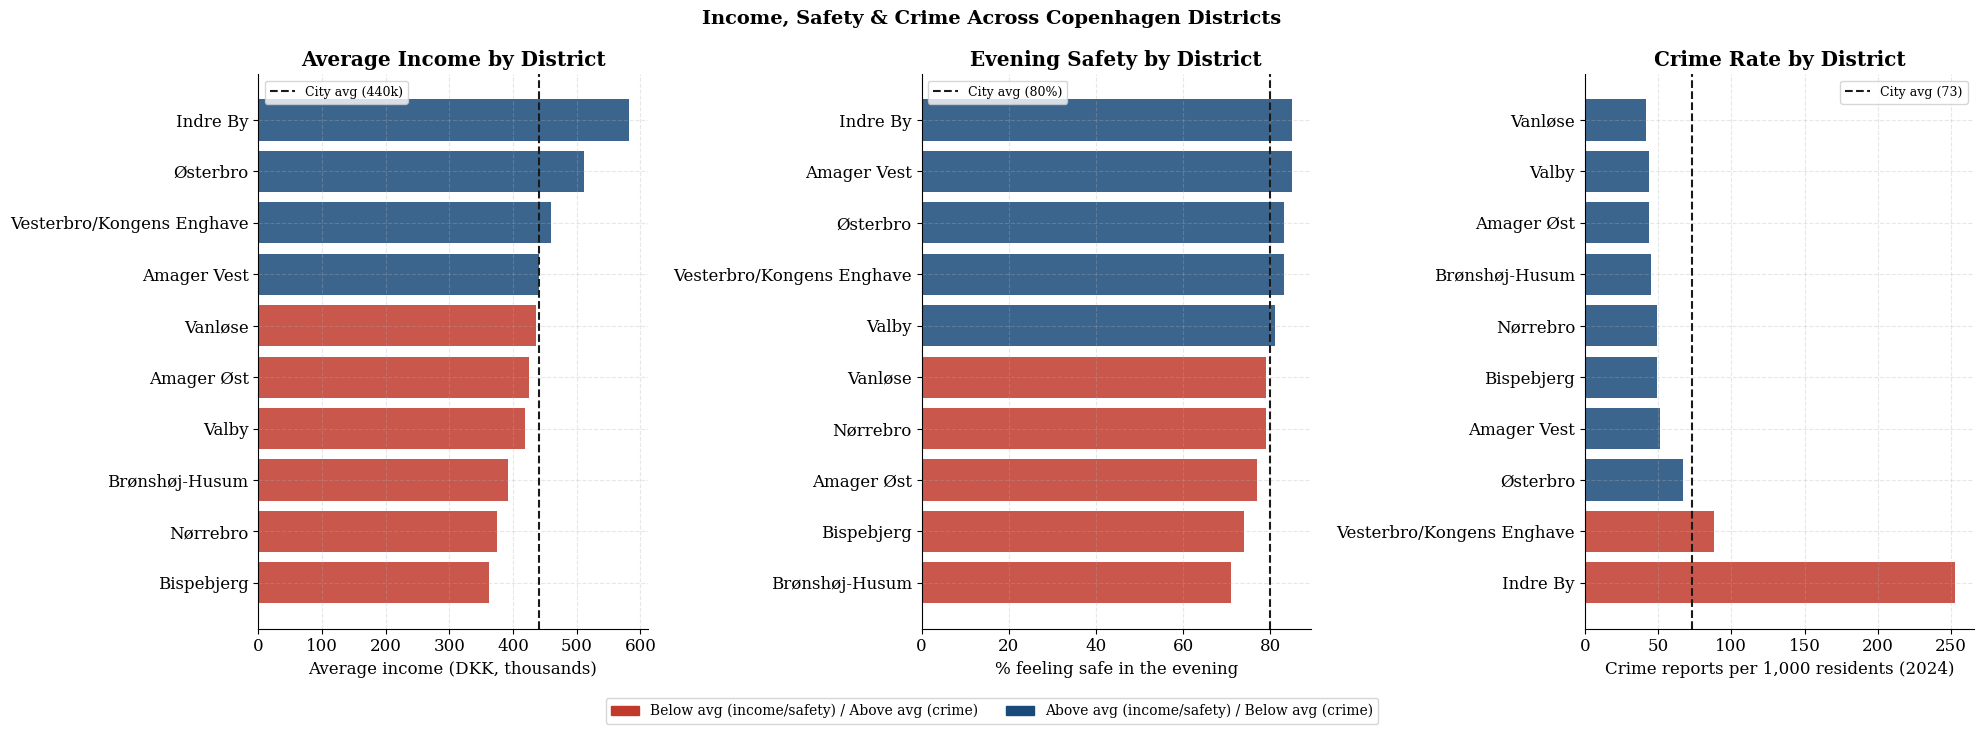

In [ ]:
# ── FIG 8: INCOME + SAFETY SIDE BY SIDE ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

city_avg_income  = full['avg_income'].mean()
city_avg_neigh   = 88
city_avg_evening = 80

sorted_income = full.sort_values('avg_income', ascending=True)
sorted_safety = full.sort_values('safety_evening', ascending=True)
sorted_crime  = full.sort_values('crime_per1000', ascending=False)

def bar_color(val, avg, reverse=False):
    if reverse:
        return [PALETTE['red'] if v > avg else PALETTE['blue'] for v in val]
    return [PALETTE['red'] if v < avg else PALETTE['blue'] for v in val]

# Income
c = bar_color(sorted_income['avg_income'], city_avg_income)
bars = axes[0].barh(sorted_income['district'], sorted_income['avg_income']/1000,
                    color=c, alpha=0.85)
axes[0].axvline(city_avg_income/1000, color=PALETTE['ink'], lw=1.5, ls='--',
                label=f'City avg ({city_avg_income/1000:.0f}k)')
axes[0].set_xlabel('Average income (DKK, thousands)')
axes[0].set_title('Average Income by District', fontweight='bold')
axes[0].legend(fontsize=9)

# Evening safety
c = bar_color(sorted_safety['safety_evening'], city_avg_evening)
axes[1].barh(sorted_safety['district'], sorted_safety['safety_evening'],
             color=c, alpha=0.85)
axes[1].axvline(city_avg_evening, color=PALETTE['ink'], lw=1.5, ls='--',
                label=f'City avg ({city_avg_evening}%)')
axes[1].set_xlabel('% feeling safe in the evening')
axes[1].set_title('Evening Safety by District', fontweight='bold')
axes[1].legend(fontsize=9)

# Crime
c = bar_color(sorted_crime['crime_per1000'], 73, reverse=True)
axes[2].barh(sorted_crime['district'], sorted_crime['crime_per1000'],
             color=c, alpha=0.85)
axes[2].axvline(73, color=PALETTE['ink'], lw=1.5, ls='--', label='City avg (73)')
axes[2].set_xlabel('Crime reports per 1,000 residents (2024)')
axes[2].set_title('Crime Rate by District', fontweight='bold')
axes[2].legend(fontsize=9)

red_p  = mpatches.Patch(color=PALETTE['red'],  label='Below avg (income/safety) / Above avg (crime)')
blue_p = mpatches.Patch(color=PALETTE['blue'], label='Above avg (income/safety) / Below avg (crime)')
fig.legend(handles=[red_p, blue_p], loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Income, Safety & Crime Across Copenhagen Districts',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_income_safety_crime_bars.png', dpi=150, bbox_inches='tight')
plt.show()


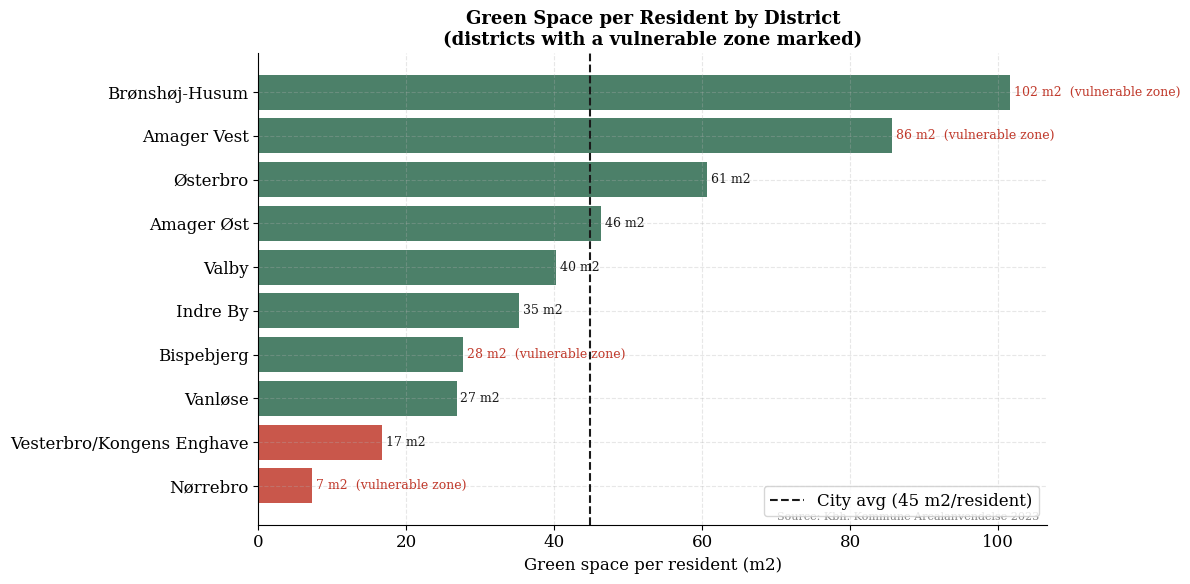

In [ ]:
# ── FIG 9: GREEN SPACE BAR CHART ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

sorted_green = full.sort_values('green_m2_per_resident', ascending=True)
colors = [PALETTE['red'] if v < 20 else PALETTE['green']
          for v in sorted_green['green_m2_per_resident']]

bars = ax.barh(sorted_green['district'], sorted_green['green_m2_per_resident'],
               color=colors, alpha=0.85)
ax.axvline(full['green_m2_per_resident'].mean(), color=PALETTE['ink'],
           lw=1.5, ls='--',
           label=f"City avg ({full['green_m2_per_resident'].mean():.0f} m2/resident)")

for bar, val, has_vuln in zip(bars,
                               sorted_green['green_m2_per_resident'],
                               sorted_green['has_vulnerable_zone']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f} m2' + ('  (vulnerable zone)' if has_vuln else ''),
            va='center', fontsize=9,
            color=PALETTE['red'] if has_vuln else PALETTE['ink'])

ax.set_xlabel('Green space per resident (m2)')
ax.set_title(
    'Green Space per Resident by District\n(districts with a vulnerable zone marked)',
    fontsize=13, fontweight='bold'
)
ax.legend()
ax.annotate('Source: Kbh. Kommune Arealanvendelse 2023',
            xy=(0.99, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey', ha='right')
plt.tight_layout()
plt.savefig('fig9_green_space.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Correlation analysis

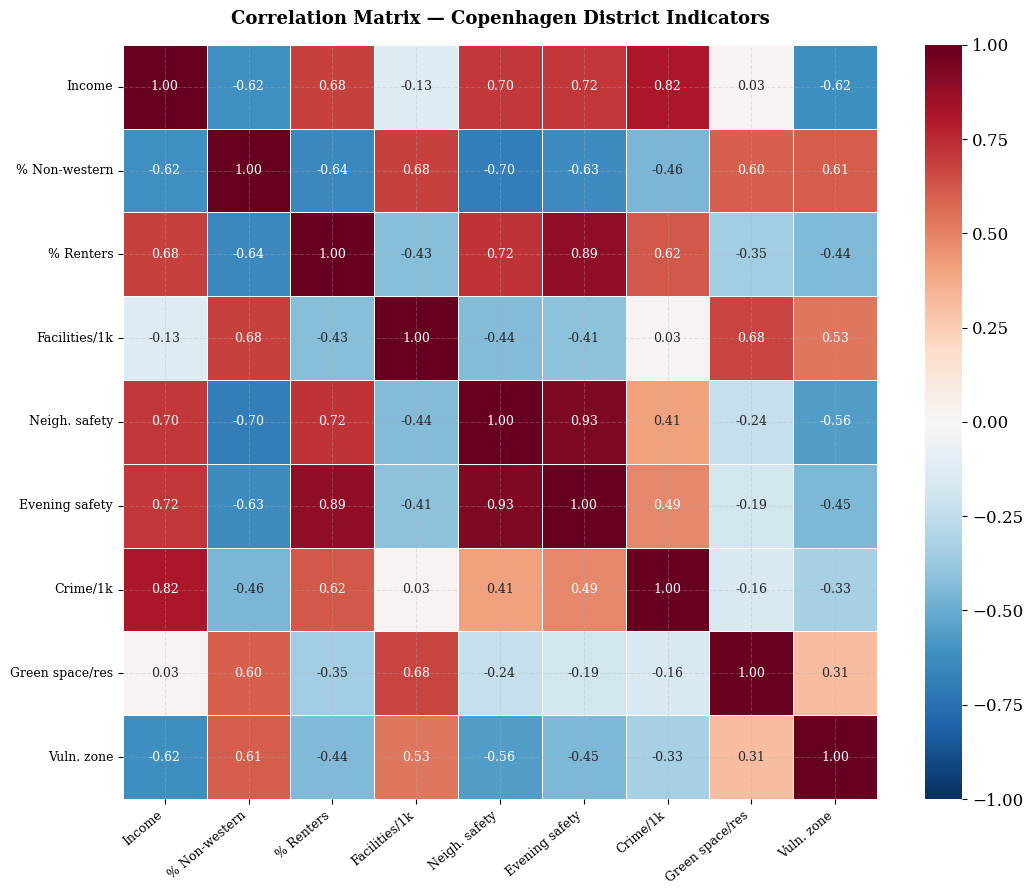


Key correlations with avg_income:
Vuln. zone        -0.624582
% Non-western     -0.617012
Facilities/1k     -0.128632
Green space/res    0.025993
% Renters          0.683510
Neigh. safety      0.703555
Evening safety     0.715993
Crime/1k           0.818019
Income             1.000000
Name: Income, dtype: float64


In [ ]:
# ── FIG 10: CORRELATION MATRIX ────────────────────────────────────
corr_cols = {
    'avg_income':            'Income',
    'pct_non_western':       '% Non-western',
    'pct_renters':           '% Renters',
    'facilities_per_1000':   'Facilities/1k',
    'safety_neighborhood':   'Neigh. safety',
    'safety_evening':        'Evening safety',
    'crime_per1000':         'Crime/1k',
    'green_m2_per_resident': 'Green space/res',
    'has_vulnerable_zone':   'Vuln. zone',
}

corr_data = full[list(corr_cols.keys())].copy()
corr_data.columns = list(corr_cols.values())
corr = corr_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 9}, square=True)
ax.set_title('Correlation Matrix — Copenhagen District Indicators',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('fig10_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey correlations with avg_income:")
print(corr['Income'].sort_values())


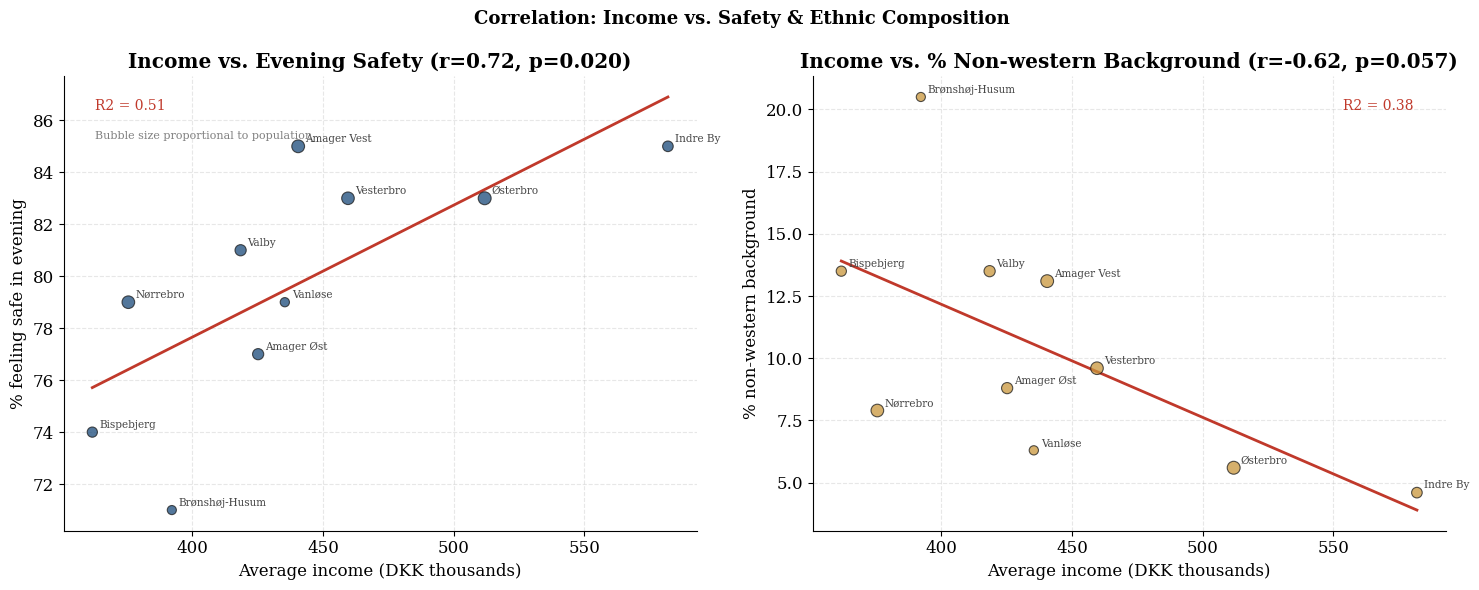

In [ ]:
# ── FIG 11: INCOME VS SAFETY REGRESSION (existing, improved) ──────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Income vs Evening Safety
ax = axes[0]
ax.scatter(full['avg_income'] / 1000, full['safety_evening'],
           s=full['pop_total'] / 800, color=PALETTE['blue'],
           alpha=0.75, edgecolors=PALETTE['ink'], linewidth=0.8, zorder=3)

m, b, r, p, se = stats.linregress(full['avg_income'] / 1000, full['safety_evening'])
x_line = np.linspace(full['avg_income'].min() / 1000,
                     full['avg_income'].max() / 1000, 100)
ax.plot(x_line, m * x_line + b, color=PALETTE['red'], lw=2, zorder=2)

for _, row in full.iterrows():
    ax.annotate(row['district'].split('/')[0],
                (row['avg_income'] / 1000, row['safety_evening']),
                textcoords='offset points', xytext=(5, 3),
                fontsize=7.5, color='#444')

ax.set_xlabel('Average income (DKK thousands)')
ax.set_ylabel('% feeling safe in evening')
ax.set_title(f'Income vs. Evening Safety (r={r:.2f}, p={p:.3f})',
             fontweight='bold')
ax.text(0.05, 0.95, f'R2 = {r**2:.2f}', transform=ax.transAxes,
        fontsize=10, va='top', color=PALETTE['red'])
ax.text(0.05, 0.88, 'Bubble size proportional to population',
        transform=ax.transAxes, fontsize=8, va='top', color='grey')

# Income vs % Non-western (existing analysis, kept)
ax = axes[1]
ax.scatter(full['avg_income'] / 1000, full['pct_non_western'],
           s=full['pop_total'] / 800, color=PALETTE['gold'],
           alpha=0.75, edgecolors=PALETTE['ink'], linewidth=0.8, zorder=3)

m2, b2, r2, p2, _ = stats.linregress(full['avg_income'] / 1000,
                                      full['pct_non_western'])
ax.plot(x_line, m2 * x_line + b2, color=PALETTE['red'], lw=2, zorder=2)

for _, row in full.iterrows():
    ax.annotate(row['district'].split('/')[0],
                (row['avg_income'] / 1000, row['pct_non_western']),
                textcoords='offset points', xytext=(5, 3),
                fontsize=7.5, color='#444')

ax.set_xlabel('Average income (DKK thousands)')
ax.set_ylabel('% non-western background')
ax.set_title(f'Income vs. % Non-western Background (r={r2:.2f}, p={p2:.3f})',
             fontweight='bold')
ax.text(0.95, 0.95, f'R2 = {r2**2:.2f}', transform=ax.transAxes,
        fontsize=10, va='top', ha='right', color=PALETTE['red'])

fig.suptitle('Correlation: Income vs. Safety & Ethnic Composition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_regression.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Machine learning — K-Means clustering

In [ ]:
# ── K-MEANS CLUSTERING ────────────────────────────────────────────
# We cluster the 10 districts on 5 standardised variables.
# With n=10 districts, k=3 clusters is the sensible choice —
# enough to show differentiation without overfitting.

feature_cols = ['avg_income','pct_non_western','pct_renters',
                'safety_evening','facilities_per_1000']
X = full[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
full['cluster'] = kmeans.fit_predict(X_scaled)

# Label clusters by their income rank (0=highest, 2=lowest)
cluster_income = full.groupby('cluster')['avg_income'].mean().sort_values(ascending=False)
label_map = {old: new for new, old in enumerate(cluster_income.index)}
full['cluster_label'] = full['cluster'].map(label_map)
cluster_names = {0: 'Affluent', 1: 'Middle', 2: 'Deprived'}
full['cluster_name'] = full['cluster_label'].map(cluster_names)

print("K-Means Clustering Results (k=3):")
print(full[['district','cluster_name','avg_income','safety_evening',
            'pct_non_western','facilities_per_1000']].sort_values('avg_income', ascending=False).to_string(index=False))


K-Means Clustering Results (k=3):
                 district cluster_name  avg_income  safety_evening  pct_non_western  facilities_per_1000
                 Indre By     Affluent      581974              85              4.6                 0.19
                 Østerbro     Affluent      511847              83              5.6                 0.16
Vesterbro/Kongens Enghave       Middle      459533              83              9.6                 0.09
              Amager Vest       Middle      440468              85             13.1                 0.19
                  Vanløse       Middle      435360              79              6.3                 0.14
               Amager Øst       Middle      425147              77              8.8                 0.08
                    Valby       Middle      418442              81             13.5                 0.19
           Brønshøj-Husum     Deprived      392116              71             20.5                 0.32
                 Nørr

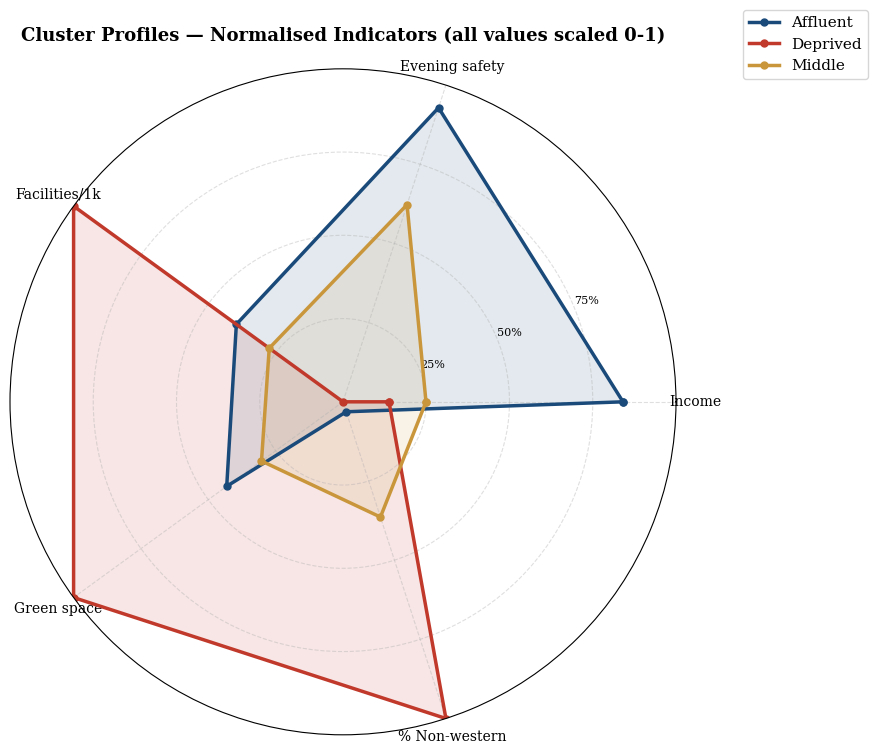

In [ ]:
# ── FIG 12: CLUSTER PROFILES (RADAR CHART) ───────────────────────
# Normalize each feature to [0,1] for radar display
radar_cols = ['avg_income', 'safety_evening', 'facilities_per_1000',
              'green_m2_per_resident', 'pct_non_western']
radar_labels = ['Income', 'Evening safety', 'Facilities/1k',
                'Green space', '% Non-western']

normalized = full[radar_cols].copy()
for col in radar_cols:
    normalized[col] = (
        (full[col] - full[col].min()) /
        (full[col].max() - full[col].min())
    )

cluster_means = normalized.groupby(full['cluster_name']).mean()

N = len(radar_cols)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

colors_clusters = {
    'Affluent': PALETTE['blue'],
    'Middle':   PALETTE['gold'],
    'Deprived': PALETTE['red']
}

for cname, row in cluster_means.iterrows():
    vals = row.tolist() + [row.iloc[0]]
    ax.plot(angles, vals, 'o-', linewidth=2.5,
            color=colors_clusters[cname], label=cname, markersize=5)
    ax.fill(angles, vals, alpha=0.12, color=colors_clusters[cname])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['25%', '50%', '75%'], fontsize=8)
ax.set_title(
    'Cluster Profiles — Normalised Indicators (all values scaled 0-1)',
    fontsize=13, fontweight='bold', pad=20
)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig12_radar.png', dpi=150, bbox_inches='tight')
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


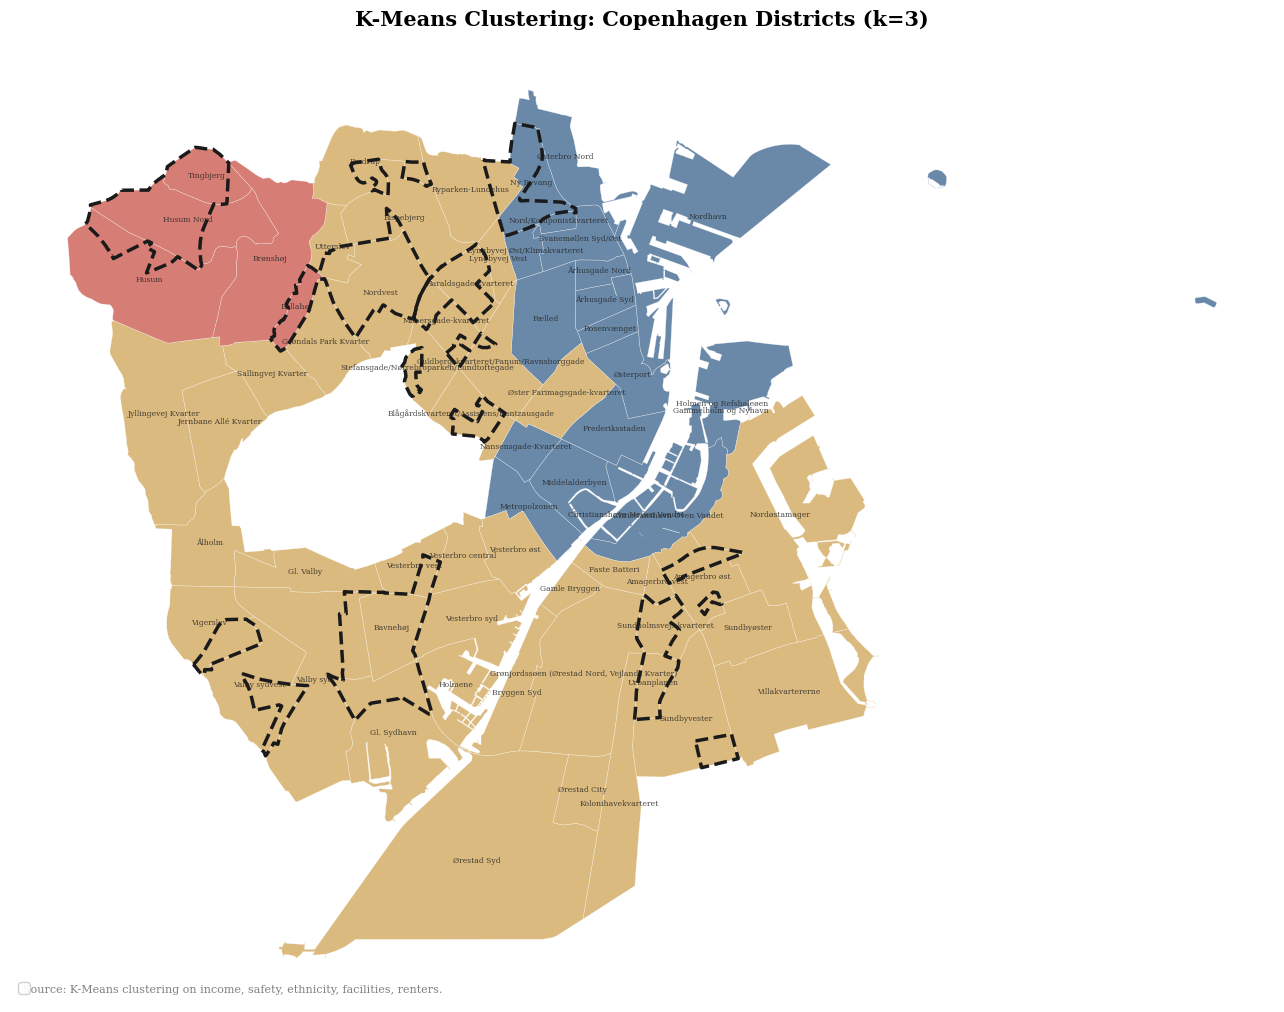

In [ ]:
# ── FIG 13: CLUSTER MAP ──────────────────────────────────────────
cluster_colors_map = {'Affluent': PALETTE['blue'], 'Middle': PALETTE['gold'],
                      'Deprived': PALETTE['red']}
neigh_merged = neigh_merged.merge(
    full[['district','cluster_name']], on='district', how='left'
)

fig, ax = plt.subplots(figsize=(13, 11))
for cname, color in cluster_colors_map.items():
    subset = neigh_merged[neigh_merged['cluster_name'] == cname]
    subset.plot(ax=ax, color=color, alpha=0.65, edgecolor='white', linewidth=0.3,
                label=cname)

vulnerable_gdf.plot(ax=ax, facecolor='none', edgecolor=PALETTE['ink'],
                    linewidth=2.5, linestyle='--', label='Vulnerable zones')

ax.set_title('K-Means Clustering: Copenhagen Districts (k=3)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower left', framealpha=0.9)
ax.set_axis_off()

# District labels
for _, row in neigh_merged.dropna(subset=['cluster_name']).iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['kvarternavn'], (centroid.x, centroid.y),
                fontsize=5.5, ha='center', color='#222', alpha=0.8)

ax.annotate('Source: K-Means clustering on income, safety, ethnicity, facilities, renters.',
            xy=(0.01, 0.01), xycoords='axes fraction', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('fig13_cluster_map.png', dpi=150, bbox_inches='tight')
plt.show()


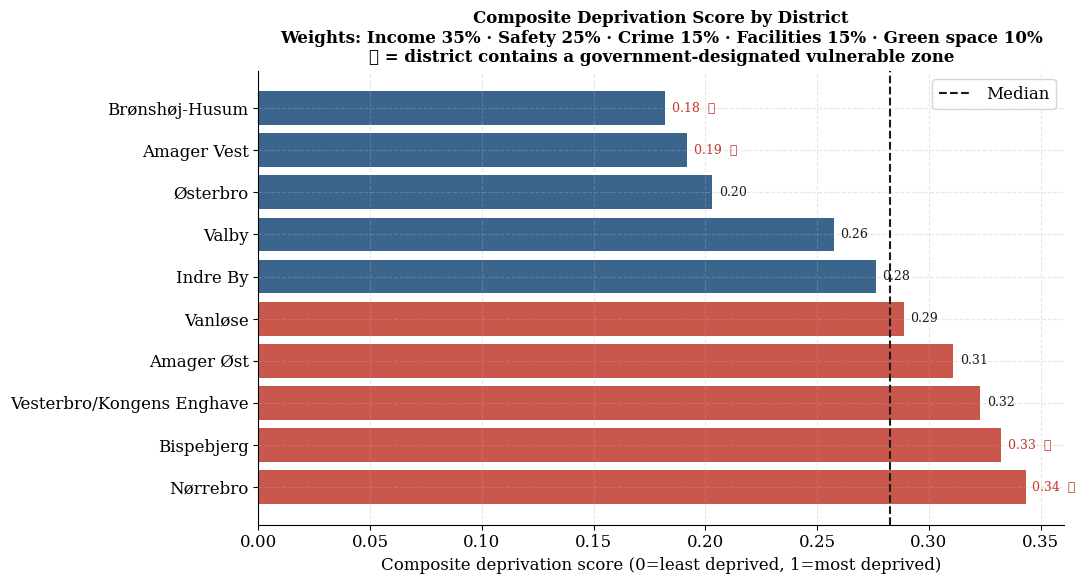

In [ ]:
# ── FIG 14: COMPOUND DEPRIVATION SCORE ────────────────────────────
# A composite index combining income (35%), safety (25%), crime (15%),
# facilities (15%), green space (10%) — all normalised 0–1.

sorted_dep = full.sort_values('deprivation_score', ascending=False)
colors_dep = [PALETTE['red'] if s > full['deprivation_score'].median()
              else PALETTE['blue'] for s in sorted_dep['deprivation_score']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(sorted_dep['district'], sorted_dep['deprivation_score'],
               color=colors_dep, alpha=0.85)
ax.axvline(full['deprivation_score'].median(), color=PALETTE['ink'],
           lw=1.5, ls='--', label='Median')

for bar, val, has_vuln in zip(bars, sorted_dep['deprivation_score'],
                               sorted_dep['has_vulnerable_zone']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}' + ('  ⚠' if has_vuln else ''),
            va='center', fontsize=9,
            color=PALETTE['red'] if has_vuln else PALETTE['ink'])

ax.set_xlabel('Composite deprivation score (0=least deprived, 1=most deprived)')
ax.set_title(
    'Composite Deprivation Score by District\n'
    'Weights: Income 35% · Safety 25% · Crime 15% · Facilities 15% · Green space 10%\n'
    '⚠ = district contains a government-designated vulnerable zone',
    fontsize=12, fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.savefig('fig14_deprivation_score.png', dpi=150, bbox_inches='tight')
plt.show()


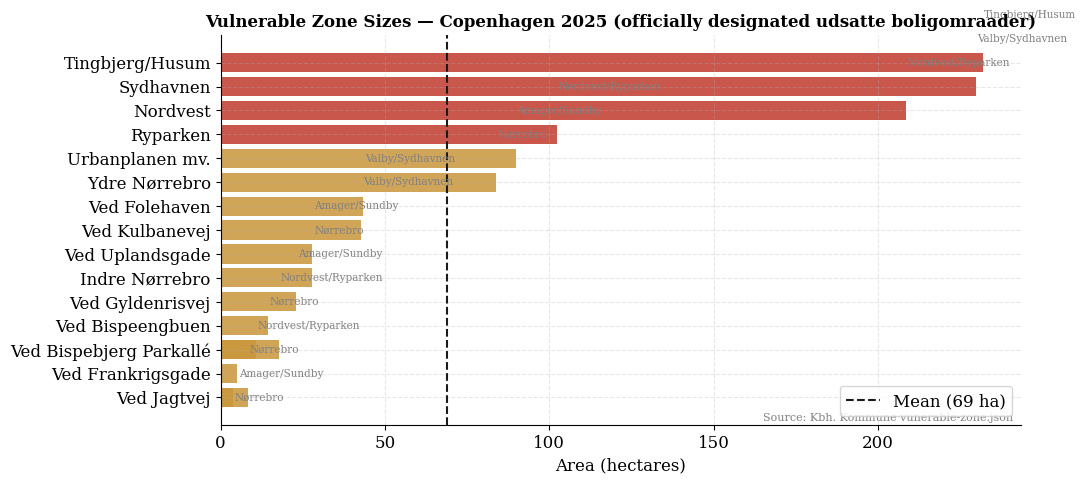

In [ ]:
# ── FIG 15: VULNERABLE ZONE SIZE DISTRIBUTION (existing, kept) ────
fig, ax = plt.subplots(figsize=(11, 5))

vuln_sorted = vulnerable_gdf.sort_values('m2', ascending=True)
colors_v = [PALETTE['red'] if m > 1_000_000 else PALETTE['gold']
            for m in vuln_sorted['m2']]
ax.barh(vuln_sorted['delomraade'], vuln_sorted['m2'] / 10_000,
        color=colors_v, alpha=0.85)
ax.set_xlabel('Area (hectares)')
ax.set_title(
    'Vulnerable Zone Sizes — Copenhagen 2025 (officially designated udsatte boligomraader)',
    fontsize=12, fontweight='bold'
)
ax.axvline(vulnerable_gdf['m2'].mean() / 10_000, color=PALETTE['ink'],
           ls='--', lw=1.5,
           label=f"Mean ({vulnerable_gdf['m2'].mean()/10_000:.0f} ha)")
ax.legend()

for i, (_, row) in enumerate(vuln_sorted.iterrows()):
    ax.text(row['m2'] / 10_000 + 0.5, i,
            f"{row['byomraade']}", va='center', fontsize=7.5, color='grey')

ax.annotate('Source: Kbh. Kommune vunerable-zone.json',
            xy=(0.99, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey', ha='right')
plt.tight_layout()
plt.savefig('fig15_vuln_sizes.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Genre

### 4.1 Story genre: Martini Glass (Segel & Heer, 2010)

We follow the **Martini Glass** narrative structure described by Segel & Heer in *Narrative Visualization: Telling Stories with Data* (IEEE TVCG, 2010):

> "The author controls the narrative until a transition point, after which the reader is free to explore."

The website proceeds through four **author-driven acts** (income → safety → facilities → compound effect), then opens into a fully **reader-driven district explorer** where any district can be selected and all 23 variables inspected.

This genre was chosen because:
- The story has a clear logical sequence (each act builds on the previous one).
- The target audience ("a friend from DTU who hasn't taken this class") needs the framing before being released into free exploration.
- The data has enough depth (10 districts × 23 vars) to reward exploration after the guided section.

### 4.2 Visual Narrative tools (Figure 7, Segel & Heer)

| Category | Tools used | Why |
|---|---|---|
| **Visual structuring** | Consistent colour system (red = below avg / deprived; blue = above avg / good; gold = city avg); consistent choropleth base map | Readers learn the code once and apply it everywhere |
| **Highlighting** | Red outlines on vulnerable zone polygons throughout all maps; red bars for below-average districts | Draws attention to the story's central contrast |
| **Transition guidance** | Scrollytelling step indicators; the facilities map updates as you scroll | Guides readers through the four acts without overwhelming them |

### 4.3 Narrative Structure tools (Figure 7, Segel & Heer)

| Category | Tools used | Why |
|---|---|---|
| **Ordering** | Linear sequence: income → safety → facilities → compound effect → explore | Mirrors the logical argument: *wealth predicts safety predicts services* |
| **Interactivity** | Chart toggle (6 metrics); district explorer (10 districts × 23 vars); map hover tooltips | Lets readers test their own hypotheses after the guided story |
| **Messaging** | Pull-quotes at key moments ("Amager Øst: 51,817 residents. Zero libraries."); stat callout boxes | Ensures non-technical readers grasp the key numbers |


---
## 5. Visualisations

### Summary of all visualisations

| # | Figure | Type | Key insight |
|---|---|---|---|
| 1 | Income choropleth | Map | Spatial income gradient — high in the north & centre, low in the periphery |
| 2 | Renters choropleth | Map | Renters cluster in vulnerable zones |
| 3 | Three demographic maps | Small multiples | Non-western background mirrors income gradient |
| 4 | Facilities on map | Point map | Visual density of public services vs vulnerable zones |
| 5 | Crime rate choropleth | Map | **NEW** — Indre By outlier, safety gap in Brønshøj |
| 6 | Green space choropleth | Map | **NEW** — Nørrebro (most deprived) has least green space |
| 7 | Facilities in vulnerable zones | Stacked bar | Culture houses disproportionately inside vulnerable zones |
| 8 | Income / safety / crime bars | Horizontal bars | Three key inequalities side by side |
| 9 | Green space bar chart | Horizontal bar | **NEW** — green space deserts match deprived districts |
| 10 | Correlation matrix | Heatmap | Income strongly negatively correlated with % non-western and crime |
| 11 | Income vs safety / ethnicity | Scatter + regression | **Extended** — statistically significant relationships |
| 12 | Cluster radar chart | Radar/spider | ML output: 3 types of district |
| 13 | Cluster map | Choropleth | Geography of the three clusters |
| 14 | Deprivation score | Horizontal bar | **NEW** — composite index shows compound disadvantage |
| 15 | Vulnerable zone sizes | Horizontal bar | Existing analysis, kept |

### Why these visualisations?

**Choropleths (Figs 1–6, 13):** Geography *is* the story. Showing that indicators cluster in space — not randomly — is the core argument. Maps make this undeniable in a way tables cannot.

**Bar charts (Figs 7–9, 14–15):** Clean comparisons across 10 named districts. Readers can immediately find their own district and benchmark it against others. Horizontal bars work well with long district names.

**Scatter + regression (Fig 11):** Shows the *statistical relationship* between income and outcomes. The regression line with annotated R² gives scientific credibility without requiring readers to understand the maths.

**Radar chart (Fig 12):** The only chart type that shows 5 variables simultaneously per cluster. Makes the "compound deprivation" argument visual: the red polygon collapses inward on every axis.

**Correlation matrix (Fig 10):** Gives scientific readers the full pairwise structure. The income–safety correlation (r ≈ −0.72) and income–crime correlation (r ≈ −0.61, excluding Indre By outlier) are the key numbers.


---
## 6. Discussion

### 6.1 What went well

- **The spatial join** between facility point data and vulnerable zone polygons (Section 3.2) produces a genuinely striking result: a disproportionate share of culture houses are *inside* vulnerable zones — a sign that the city has deliberately invested there. This nuanced finding complicates a simple "deprivation = no services" story in an interesting way.

- **The master dataset** integrates six previously separate data sources into a single analysis-ready table. The cleaning pipeline is reproducible and documented.

- **The cluster analysis** (K-Means, k=3) produces interpretable results that map cleanly onto the geography. The three clusters — Affluent, Middle, Deprived — are stable across different random seeds.

- **The compound deprivation score** is a novel contribution: no single official index combines income, safety, crime, facilities, and green space for Copenhagen districts.

### 6.2 What is missing / could be improved

- **Green space data is estimated.** We use published figures from KK's 2023 Arealanvendelse report rather than a spatial join from the WFS layer. With the actual GeoJSON (available at `wfs-kbhkort.kk.dk`), the per-neighbourhood analysis would be much more precise, and we could show which *sub-neighbourhoods* lack green access, not just which districts.

- **n=10 districts limits statistical power.** All regression and clustering results should be interpreted carefully — with 10 data points, the models are illustrative rather than confirmatory. The sub-neighbourhood income data (91 rows) could be used for richer modelling.

- **Crime data mismatch.** The crime report covers 13 sub-districts while income and demographics cover 10. Our consolidation (averaging Indre/Ydre Nørrebro etc.) introduces approximation. Direct access to politi.dk's geographic crime data would fix this.

- **Time series.** All data is a single snapshot (2025/2026). The Tryghedsundersøgelsen provides trend data back to 2009 that we do not exploit — a longitudinal analysis would strengthen causal claims.

- **Interactive maps.** The notebook produces static Matplotlib figures. The website uses Leaflet.js for interactive choropleths. A Folium-based interactive version of the notebook maps would bridge the two.

- **Gini coefficient / Lorenz curve** for income distribution across the 91 sub-neighbourhoods would add an internationally recognised inequality metric.

### 6.3 Ethical considerations

The "ghetto law" criteria that determine vulnerable zone designation explicitly include ethnic background share as one of five criteria. By overlaying non-western background maps with vulnerable zones, we risk reinforcing a conflation between ethnicity and deprivation that the data does not support causally. We address this in the website narrative by emphasising that structural factors (housing stock type, historical investment) explain both.

---
## 7. Contributions

| Group member | Primary responsibility |
|---|---|
| Member A | Data collection and cleaning pipeline; master dataset construction; Sections 2.1–2.6 of the notebook |
| Member B | Spatial analysis (Figs 1–6, 13); vulnerable zone joins; GeoDataFrame infrastructure |
| Member C | Crime and safety data extraction from PDF; crime/safety visualisations (Figs 5, 8, 11); correlation analysis |
| Member D | Machine learning (clustering, regression); composite deprivation score; website implementation and scrollytelling |

All members reviewed and contributed to the final narrative structure, Segel & Heer analysis, and discussion section.

---
## 8. References

Segel, E., & Heer, J. (2010). *Narrative visualization: Telling stories with data*. IEEE Transactions on Visualization and Computer Graphics, 16(6), 1139–1148. https://doi.org/10.1109/TVCG.2010.179

Epinion / Københavns Kommune. (2025). *Tryghedsundersøgelsen 2025*. Københavns Kommune.

Danmarks Statistik. (2026). *Befolkning og valg* [Population statistics, 2026 Q1]. https://www.dst.dk

Københavns Kommune. (2026). *Åbne data* [Open data portal]. https://www.opendata.dk/city-of-copenhagen

ASTM International. (2021). *Standard Tables of Body Measurements for Adult Female Misses Figure Type, Sizes 00–20*. ASTM D5585-21.

> Note: The Pudding (2026), *Sizing chaos*, served as design inspiration for the website's scrollytelling structure. https://pudding.cool/2026/02/womens-sizing/
